# Inspect Episode0 Stage Data

Load saved stage DataFrames and view basic info/head.

In [2]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()
out_dir = ROOT / "data" / "outputs"
list(out_dir.glob("episode0_stage_*.pkl"))

[]

In [3]:
# Choose which stage to inspect
stage = "pv"  # options: sdf1, pv, sdf2, fc2, final




df_macro = pd.read_pickle("/Users/ballinliu/Desktop/PHD/Project1/DL-AP/data/outputs/ep2_stage_pv_macro.pkl")
print(stage, "macro df shape:", df_macro.shape)
display(df_macro.head())

pv macro df shape: (3000, 9)


,path,t,branch,K,C,LnK,Hatc,n_firms,M
0,0,0,-1,200.125275,184.030640,5.298944,-0.083830,200,NaN
1,0,1,0,201.461197,177.980133,5.305597,-0.123914,200,5.931653
2,0,1,1,201.461197,182.914673,5.305597,-0.096566,200,5.474244
3,0,1,-1,221.461197,201.762329,5.400247,-0.093146,220,5.931653
4,0,2,0,222.707016,199.511063,5.405857,-0.109976,220,5.452475


In [5]:
df_macro

,path,t,branch,K,C,LnK,Hatc,n_firms,M
0,0,0,-1,200.125275,184.030640,5.298944,-0.083830,200,NaN
1,0,1,0,201.461197,177.980133,5.305597,-0.123914,200,5.931653
2,0,1,1,201.461197,182.914673,5.305597,-0.096566,200,5.474244
3,0,1,-1,221.461197,201.762329,5.400247,-0.093146,220,5.931653
4,0,2,0,222.707016,199.511063,5.405857,-0.109976,220,5.452475
...,...,...,...,...,...,...,...,...,...
2995,99,9,0,373.739685,299.836975,5.923560,-0.220308,360,2.567469
2996,99,9,1,373.739685,314.326782,5.923560,-0.173114,360,2.161467
2997,99,9,-1,393.739685,328.744507,5.975690,-0.180397,380,2.567469
2998,99,10,0,395.836487,341.052582,5.981001,-0.148953,380,2.196494



## bz 联合分布检查
从缓存路径读取多个 stage 的 pkl，绘制 b 与 z 的联合分布（散点 + 2D KDE）。


Plotting ep1_stage_pv.pkl, shape=(10000, 27)


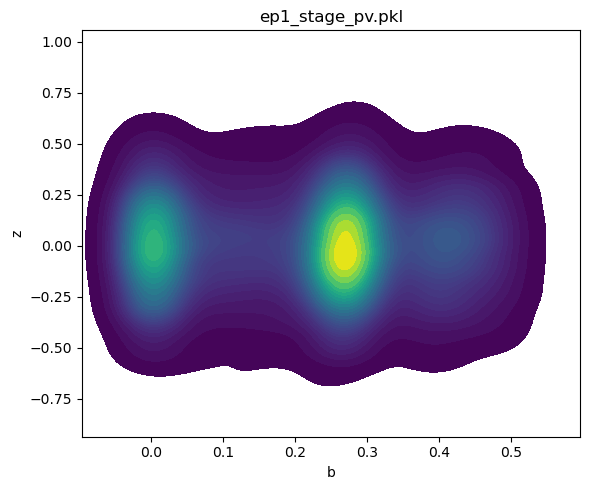

skip ep1_stage_pv_macro.pkl: missing b/z columns
skip ep1_stage_sdf1_macro.pkl: missing b/z columns
Plotting ep1_stage_sdf1.pkl, shape=(10000, 27)


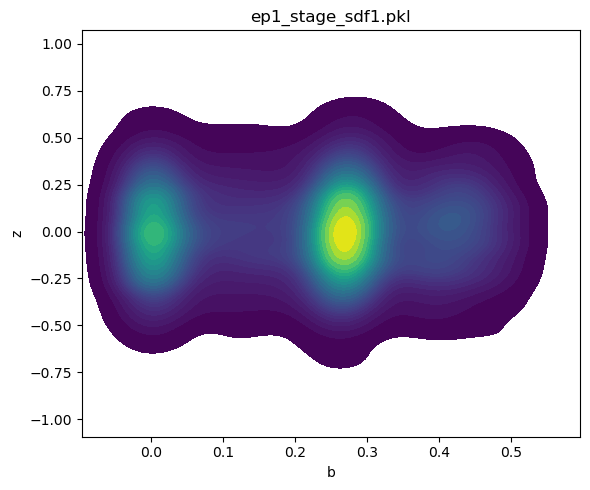

skip ep1_stage_sdf2_macro.pkl: missing b/z columns
Plotting ep1_stage_sdf2.pkl, shape=(10000, 27)


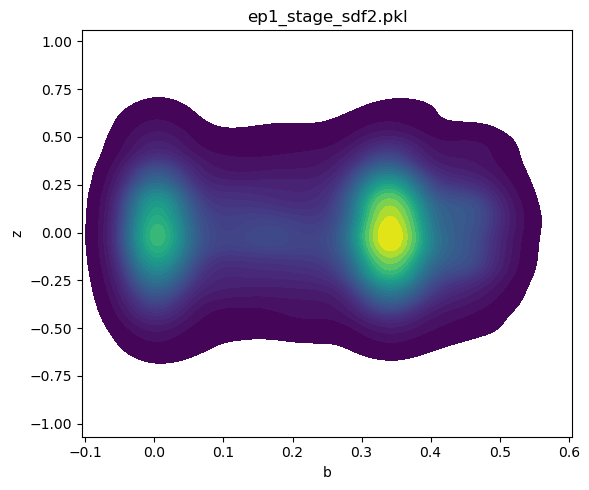

skip ep2_stage_sdf1_macro.pkl: missing b/z columns
Plotting ep2_stage_sdf1.pkl, shape=(10000, 27)


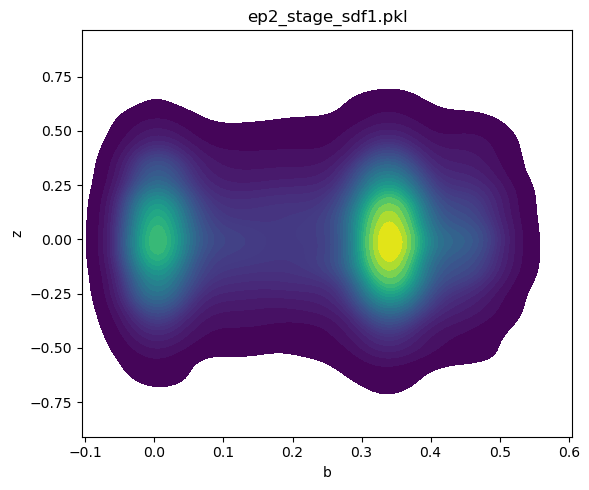

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

paths = [
    Path('/Users/ballinliu/Desktop/PHD/Project1/cachedir/20260131_1936/data/outputs/ep1_stage_pv.pkl'),
    Path('/Users/ballinliu/Desktop/PHD/Project1/cachedir/20260131_1936/data/outputs/ep1_stage_pv_macro.pkl'),
    Path('/Users/ballinliu/Desktop/PHD/Project1/cachedir/20260131_1936/data/outputs/ep1_stage_sdf1_macro.pkl'),
    Path('/Users/ballinliu/Desktop/PHD/Project1/cachedir/20260131_1936/data/outputs/ep1_stage_sdf1.pkl'),
    Path('/Users/ballinliu/Desktop/PHD/Project1/cachedir/20260131_1936/data/outputs/ep1_stage_sdf2_macro.pkl'),
    Path('/Users/ballinliu/Desktop/PHD/Project1/cachedir/20260131_1936/data/outputs/ep1_stage_sdf2.pkl'),
    Path('/Users/ballinliu/Desktop/PHD/Project1/cachedir/20260131_1936/data/outputs/ep2_stage_sdf1_macro.pkl'),
    Path('/Users/ballinliu/Desktop/PHD/Project1/cachedir/20260131_1936/data/outputs/ep2_stage_sdf1.pkl'),
]

for p in paths:
    if not p.exists():
        print(f"missing: {p}")
        continue
    df = pd.read_pickle(p)
    if not {'b','z'}.issubset(df.columns):
        print(f"skip {p.name}: missing b/z columns")
        continue
    if len(df) > 10000:
        df = df.sample(n=10000, random_state=42)
    print(f"Plotting {p.name}, shape={df.shape}")
    plt.figure(figsize=(6,5))
    sns.kdeplot(x=df['b'], y=df['z'], fill=True, cmap='viridis', levels=30, thresh=0.01)
    plt.xlabel('b')
    plt.ylabel('z')
    plt.title(p.name)
    plt.tight_layout()
    plt.show()


## EP0 b-z 联合分布 (fc2/pv/sdf stages)

skip ep2_stage_fc2_macro.pkl: missing b/z columns
Plotting ep2_stage_fc2.pkl, shape=(10000, 27)


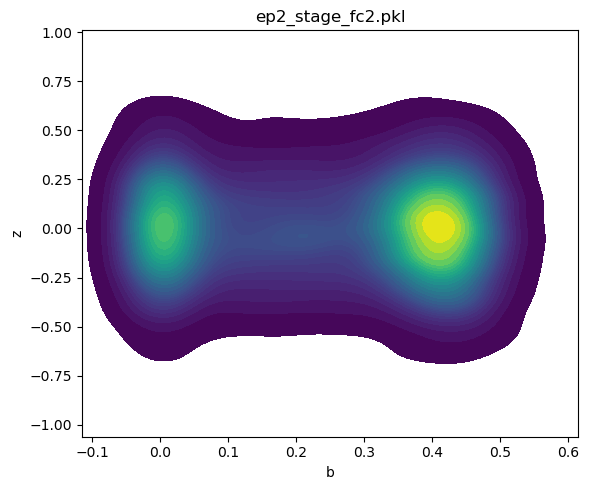

Plotting ep2_stage_pv.pkl, shape=(10000, 27)


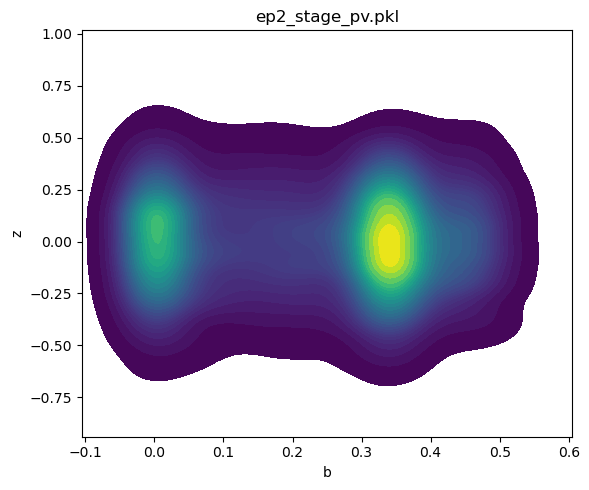

Plotting ep2_stage_sdf1.pkl, shape=(10000, 27)


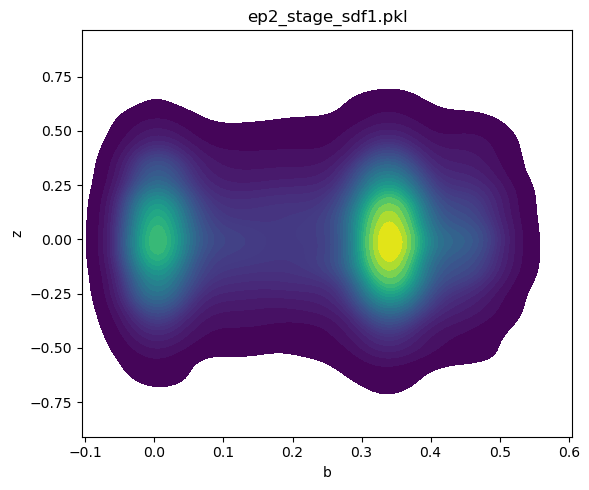

Plotting ep2_stage_sdf2.pkl, shape=(10000, 27)


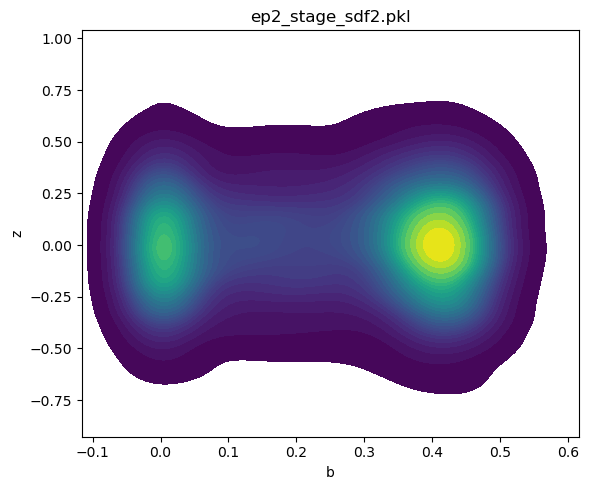

In [4]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ep = 2
paths = [
    Path(f'/Users/ballinliu/Desktop/PHD/Project1/cachedir/20260131_1936/data/outputs/ep{ep}_stage_fc2_macro.pkl'),
    Path(f'/Users/ballinliu/Desktop/PHD/Project1/cachedir/20260131_1936/data/outputs/ep{ep}_stage_fc2.pkl'),
    Path(f'/Users/ballinliu/Desktop/PHD/Project1/cachedir/20260131_1936/data/outputs/ep{ep}_stage_pv.pkl'),
    Path(f'/Users/ballinliu/Desktop/PHD/Project1/cachedir/20260131_1936/data/outputs/ep{ep}_stage_sdf1.pkl'),
    Path(f'/Users/ballinliu/Desktop/PHD/Project1/cachedir/20260131_1936/data/outputs/ep{ep}_stage_sdf2.pkl'),
]

for p in paths:
    if not p.exists():
        print(f"missing: {p}")
        continue
    df = pd.read_pickle(p)
    if not {'b','z'}.issubset(df.columns):
        print(f"skip {p.name}: missing b/z columns")
        continue
    if len(df) > 10000:
        df = df.sample(n=10000, random_state=42)
    print(f"Plotting {p.name}, shape={df.shape}")
    plt.figure(figsize=(6,5))
    sns.kdeplot(x=df['b'], y=df['z'], fill=True, cmap='viridis', levels=30, thresh=0.01)
    plt.xlabel('b')
    plt.ylabel('z')
    plt.title(p.name)
    plt.tight_layout()
    plt.show()


In [5]:
df

,path,t,branch,ID,entry,b,z,ETA,i,x,...,Bar_i,Bar_z,P,bp0,bpI,bp,Y,I,Phi,C
360719,41,6,0,c5fb28347f5e4d0d9c9ee12a7075004d,0.0,0.431043,-0.327059,0.0,0.043493,-0.077704,...,0.361495,5.434077e-03,0.104192,0.459412,0.439000,0.452033,0.721313,0.119245,4.897526e-03,0.597170
439492,50,6,1,c7a522141a064dcfb9f995940ab33d3f,0.0,0.000000,-0.155632,0.0,0.058266,0.089230,...,0.450658,6.382409e-05,0.193186,0.437205,0.572565,0.498206,0.940688,0.126859,6.209955e-05,0.813766
122246,14,1,1,5114775a17d049548557e088d0a82f50,0.0,0.141768,0.072593,0.0,0.095905,-0.005800,...,0.411542,3.746441e-04,0.157783,0.456277,0.514059,0.480057,1.600339,0.208216,5.801886e-04,1.391543
98829,11,5,0,2b9d0e58fc694ee192e296cffecbcd12,0.0,0.255169,0.332441,0.0,0.177825,-0.022873,...,0.438212,7.204198e-04,0.144699,0.448567,0.529256,0.483926,1.918659,0.249476,1.198238e-03,1.667985
685941,78,9,1,b279d68f2ce249239ab5fb6e2358dcd6,0.0,0.391557,-0.027467,0.0,0.017975,-0.031385,...,0.405589,5.291130e-03,0.104728,0.448924,0.499569,0.469465,1.331728,0.144069,7.259913e-03,1.180399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
524507,60,4,1,555738c49a064c78a4f65ae16e7118fa,0.0,0.075308,-0.040505,0.0,0.012214,-0.052833,...,0.401644,2.872304e-04,0.163099,0.460164,0.515575,0.482420,0.654301,0.075149,1.971283e-04,0.578955
229201,26,4,-1,26d199f64ccd4f18ae7434c2e96e1164,0.0,0.000000,-0.284822,0.0,0.031371,-0.041559,...,0.274374,8.948411e-13,0.554843,0.216669,0.847715,0.389812,0.725415,0.109192,7.743952e-13,0.616223
627000,72,1,-1,8438934a318642d1a359abaceec224bf,0.0,0.063162,-0.280144,0.0,0.148367,-0.026821,...,0.278215,7.627916e-11,0.465932,0.236566,0.832600,0.402392,1.078960,0.207201,9.708752e-11,0.871759
24923,2,9,1,cd59436f3f164b499b333ea1c631d537,0.0,0.000000,0.165598,0.0,0.120403,-0.022571,...,0.462433,9.868493e-06,0.230523,0.439422,0.577423,0.503238,1.164584,0.157128,1.072687e-05,1.007445


## b-z 与 P/Q 的 3D 可视化

skip ep0_stage_pv.pkl: missing b/z or P/Q columns
Plotting 3D for ep1_stage_pv.pkl, shape=(10000, 27)


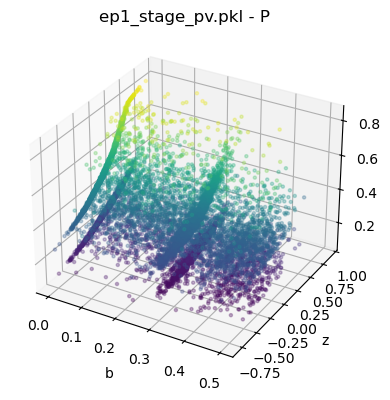

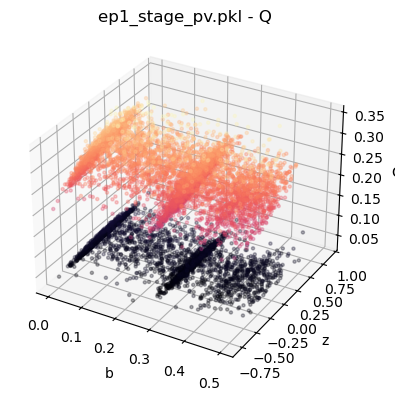

In [6]:

import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from pathlib import Path

paths = [
    Path('/Users/ballinliu/Desktop/PHD/Project1/cachedir/20260131_1936/data/outputs/ep0_stage_pv.pkl'),
    Path('/Users/ballinliu/Desktop/PHD/Project1/cachedir/20260131_1936/data/outputs/ep1_stage_pv.pkl'),
]

for p in paths:
    if not p.exists():
        print(f"missing: {p}")
        continue
    df = pd.read_pickle(p)
    needed = {'b','z'}
    has_p = 'P' in df.columns
    has_q = 'Q' in df.columns
    if not needed.issubset(df.columns) or (not has_p and not has_q):
        print(f"skip {p.name}: missing b/z or P/Q columns")
        continue
    if len(df) > 10000:
        df = df.sample(n=10000, random_state=42)
    print(f"Plotting 3D for {p.name}, shape={df.shape}")
    if has_p:
        fig = plt.figure(figsize=(5,4))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(df['b'], df['z'], df['P'], s=5, alpha=0.3, c=df['P'], cmap='viridis')
        ax.set_xlabel('b'); ax.set_ylabel('z'); ax.set_zlabel('P')
        ax.set_title(f"{p.name} - P")
        plt.tight_layout()
        plt.show()
    if has_q:
        fig = plt.figure(figsize=(5,4))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(df['b'], df['z'], df['Q'], s=5, alpha=0.3, c=df['Q'], cmap='magma')
        ax.set_xlabel('b'); ax.set_ylabel('z'); ax.set_zlabel('Q')
        ax.set_title(f"{p.name} - Q")
        plt.tight_layout()
        plt.show()


### b-z 平滑热力 (P/Q)

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy.ndimage import gaussian_filter

paths = [
    Path('/Users/ballinliu/Desktop/PHD/Project1/cachedir/20260131_1936/data/outputs/ep0_stage_pv.pkl'),
    Path('/Users/ballinliu/Desktop/PHD/Project1/cachedir/20260131_1936/data/outputs/ep1_stage_pv.pkl'),
]

for p in paths:
    if not p.exists():
        print(f"missing: {p}")
        continue
    df = pd.read_pickle(p)
    if not {'b','z'}.issubset(df.columns):
        print(f"skip {p.name}: missing b/z columns")
        continue
    if len(df) > 10000:
        df = df.sample(n=10000, random_state=42)
    for target in ['P','Q']:
        if target not in df.columns:
            continue
        b = df['b']; z = df['z']; v = df[target]
        # binning
        nbins = 40
        b_bins = np.linspace(b.min(), b.max(), nbins+1)
        z_bins = np.linspace(z.min(), z.max(), nbins+1)
        b_idx = np.digitize(b, b_bins) - 1
        z_idx = np.digitize(z, z_bins) - 1
        grid = np.full((nbins, nbins), np.nan)
        counts = np.zeros((nbins, nbins))
        sums = np.zeros((nbins, nbins))
        for bi, zi, val in zip(b_idx, z_idx, v):
            if 0 <= bi < nbins and 0 <= zi < nbins:
                counts[bi, zi] += 1
                sums[bi, zi] += val
        mask = counts > 0
        grid[mask] = sums[mask] / counts[mask]
        # smooth
        smoothed = gaussian_filter(np.nan_to_num(grid, nan=np.nanmean(grid[np.isfinite(grid)])), sigma=1)
        extent = [b_bins[0], b_bins[-1], z_bins[0], z_bins[-1]]
        plt.figure(figsize=(6,5))
        plt.imshow(smoothed.T, origin='lower', extent=extent, aspect='auto', cmap='viridis')
        plt.colorbar(label=target)
        plt.xlabel('b'); plt.ylabel('z'); plt.title(f"{p.name} - {target} (smoothed)")
        plt.tight_layout()
        plt.show()


### b-z 与 P/Q 平滑 3D 曲面

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from pathlib import Path
from scipy.ndimage import gaussian_filter

paths = [
    Path('/Users/ballinliu/Desktop/PHD/Project1/cachedir/20260131_1936/data/outputs/ep0_stage_pv.pkl'),
    Path('/Users/ballinliu/Desktop/PHD/Project1/cachedir/20260131_1936/data/outputs/ep1_stage_pv.pkl'),
]

for p in paths:
    if not p.exists():
        print(f"missing: {p}")
        continue
    df = pd.read_pickle(p)
    if not {'b','z'}.issubset(df.columns):
        print(f"skip {p.name}: missing b/z columns")
        continue
    if len(df) > 10000:
        df = df.sample(n=10000, random_state=42)
    for target in ['P','Q']:
        if target not in df.columns:
            continue
        b = df['b']; z = df['z']; v = df[target]
        nbins = 40
        b_bins = np.linspace(b.min(), b.max(), nbins+1)
        z_bins = np.linspace(z.min(), z.max(), nbins+1)
        b_idx = np.digitize(b, b_bins) - 1
        z_idx = np.digitize(z, z_bins) - 1
        grid = np.full((nbins, nbins), np.nan)
        counts = np.zeros((nbins, nbins))
        sums = np.zeros((nbins, nbins))
        for bi, zi, val in zip(b_idx, z_idx, v):
            if 0 <= bi < nbins and 0 <= zi < nbins:
                counts[bi, zi] += 1
                sums[bi, zi] += val
        mask = counts > 0
        grid[mask] = sums[mask] / counts[mask]
        fill_val = np.nanmean(grid[np.isfinite(grid)]) if np.isfinite(grid).any() else 0.0
        smoothed = gaussian_filter(np.nan_to_num(grid, nan=fill_val), sigma=1)
        b_centers = 0.5 * (b_bins[:-1] + b_bins[1:])
        z_centers = 0.5 * (z_bins[:-1] + z_bins[1:])
        B, Z = np.meshgrid(b_centers, z_centers, indexing='ij')
        fig = plt.figure(figsize=(6,4.5))
        ax = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(B, Z, smoothed, cmap='viridis', linewidth=0, antialiased=True, alpha=0.9)
        fig.colorbar(surf, shrink=0.6, aspect=10, label=target)
        ax.set_xlabel('b'); ax.set_ylabel('z'); ax.set_zlabel(target)
        ax.set_title(f"{p.name} - {target} (smoothed surface)")
        plt.tight_layout()
        plt.show()


### 使用对应 ckpt 预测网格 (P/Q) - 其他变量取均值

skip ep0_stage_pv.pkl: missing required columns
loaded ckpt: /Users/ballinliu/Desktop/PHD/Project1/cachedir/20260131_1936/checkpoints/ep1_policy_value.pt
Means for ep1_stage_pv.pkl: {'eta': 1.0, 'i': 0.10000465572030509, 'x': 0.0036823221629180398, 'hatcf': -0.10022950938739736, 'lnkf': 3.056577524225744}


/var/folders/r9/cszsqrws3bvczrrd1rnjqg600000gn/T/ipykernel_13229/333707304.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt, map_location=device)

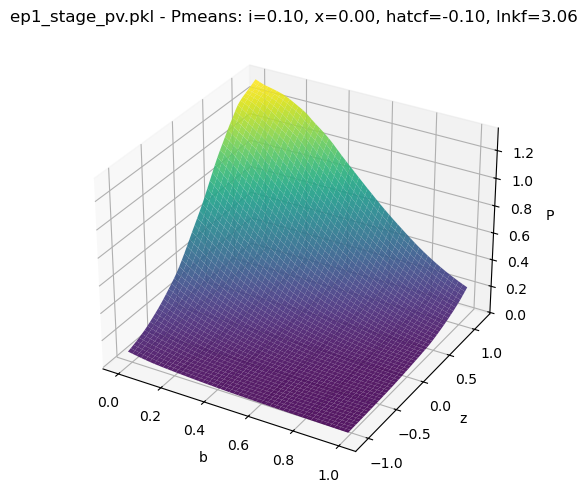

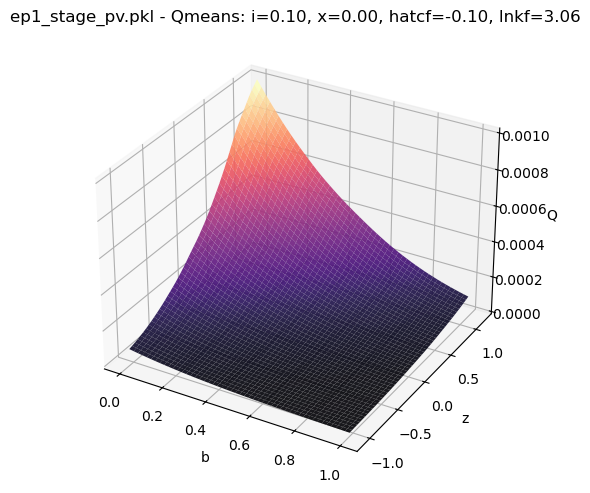

In [3]:

import sys
from pathlib import Path
import torch
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# resolve project root
ROOT = Path.cwd().resolve()
if ROOT.name == 'experiments':
    ROOT = ROOT.parent
if not (ROOT / 'models').exists():
    ROOT = Path('/Users/ballinliu/Desktop/PHD/Project1/DL-AP')
sys.path.append(str(ROOT))

from models import PolicyValueModel
from config import Config


def load_policy(ep, base_dir):
    ckpt = base_dir / 'checkpoints' / f'ep{ep}_policy_value.pt'
    model = PolicyValueModel().to(device)
    if ckpt.exists():
        state = torch.load(ckpt, map_location=device)
        model.load_state_dict(state, strict=False)
        print(f"loaded ckpt: {ckpt}")
    else:
        print(f"missing ckpt: {ckpt}, using random init")
    model.eval()
    return model

base_dir = Path('/Users/ballinliu/Desktop/PHD/Project1/cachedir/20260131_1936')
paths = [
    base_dir / 'data/outputs/ep0_stage_pv.pkl',
    base_dir / 'data/outputs/ep1_stage_pv.pkl',
]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
Config.DEVICE = device

for p in paths:
    if not p.exists():
        print(f"missing: {p}")
        continue
    df = pd.read_pickle(p)
    required = {'b','z','P','Q','i','x','Hatcf','LnKF'}
    if not required.issubset(df.columns):
        print(f"skip {p.name}: missing required columns")
        continue
    ep_str = [seg for seg in p.name.split('_') if seg.startswith('ep')]
    ep_num = int(ep_str[0][2:]) if ep_str else 0
    model = load_policy(ep_num, base_dir)

    means = {
        'eta': 1.0,
        'i': df['i'].mean(),
        'x': df['x'].mean(),
        'hatcf': df['Hatcf'].mean(),
        'lnkf': df['LnKF'].mean(),
    }
    print(f"Means for {p.name}: {means}")

    b_min, b_max = df['b'].min(), 1
    z_min, z_max = df['z'].min(), df['z'].max()
    b_grid = torch.linspace(float(b_min), float(b_max), 50, device=device)
    z_grid = torch.linspace(float(z_min), float(z_max), 50, device=device)
    B, Z = torch.meshgrid(b_grid, z_grid, indexing='ij')
    base = torch.stack(
        [
            B.reshape(-1),
            Z.reshape(-1),
            torch.full_like(B.reshape(-1), means['eta']),
            torch.full_like(B.reshape(-1), means['i']),
            torch.full_like(B.reshape(-1), means['x']),
            torch.full_like(B.reshape(-1), means['hatcf']),
            torch.full_like(B.reshape(-1), means['lnkf']),
        ],
        dim=1,
    )
    with torch.no_grad():
        out = model(base)
        P = out.P.reshape(B.shape).cpu().numpy()
        Q = out.Q.reshape(B.shape).cpu().numpy()

    for name, arr, cmap in [("P", P, 'viridis'), ("Q", Q, 'magma')]:
        fig = plt.figure(figsize=(7,5))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(B.cpu().numpy(), Z.cpu().numpy(), arr, cmap=cmap, linewidth=0, antialiased=True, alpha=0.9)
        ax.set_xlabel('b'); ax.set_ylabel('z'); ax.set_zlabel(name)
        ax.set_title(f"{p.name} - {name}means: i={means['i']:.2f}, x={means['x']:.2f}, hatcf={means['hatcf']:.2f}, lnkf={means['lnkf']:.2f}")
        plt.tight_layout()
        plt.show()


In [ ]:
# Sanity check: per-parent child residual product
import torch
from losses.q_loss import QLoss

# Construct an easy batch: 3 parents, 2 children each
batch_size = 3
Q = torch.tensor([[1.0],[1.0],[1.0]])
b = torch.tensor([[1.0],[1.0],[1.0]])
bar_i = torch.zeros(batch_size,1)  # multiplier=1
M_list = [torch.ones(batch_size,1), torch.ones(batch_size,1)]
Qsp_children = [torch.tensor([[1.0],[2.0],[3.0]]), torch.tensor([[10.0],[20.0],[30.0]])]
bar_z_children = [torch.zeros(batch_size,1), torch.zeros(batch_size,1)]
x_children = [torch.zeros(batch_size,1), torch.zeros(batch_size,1)]
z_children = [torch.zeros(batch_size,1), torch.zeros(batch_size,1)]
bar_z = torch.zeros(batch_size,1)

qloss = QLoss()
residuals = qloss.compute_main_residual(Q, b, bar_i, M_list, Qsp_children, bar_z_children, x_children, z_children)
residuals_stack = torch.stack(residuals, dim=-1)  # (batch,1,n_children)
combined = residuals_stack.prod(dim=-1)            # (batch,1)
main_loss = combined.abs().mean()

print('Residuals (child1, child2):')
print(residuals_stack.squeeze(1))
print('Per-parent product:')
print(combined.squeeze(1))
print('Main loss (mean |product|):', main_loss.item())

# Expected: residual1=b+Qsp1-Q=Qsp1, residual2=Qsp2; product per parent = Qsp1*Qsp2


In [18]:
# Step-by-step test for Episode._compute_q_loss
import torch
from training.episode import Episode
from losses.utils import compute_z_penalty
from config import Config, HyperParams

# Dummy policy/value model with deterministic outputs
class DummyPV(torch.nn.Module):
    def forward(self, firm_state):
        b = firm_state[:, 0:1]
        # Simple deterministic heads
        Q = b + 1.0
        bp0 = torch.full_like(b, 0.3)
        bpI = torch.full_like(b, 0.8)
        bar_i = torch.full_like(b, 0.5)
        bar_z = torch.zeros_like(b)
        P = torch.zeros_like(b)
        bp = bar_i * bpI + (1 - bar_i) * bp0
        return {"Q": Q, "bp0": bp0, "bpI": bpI, "bar_i": bar_i, "bar_z": bar_z, "P": P, "bp": bp}

device = torch.device('cpu')
episode = Episode(
    models={'policy_value': DummyPV()},
    optimizers={},
    config=Config,
    hyperparams=HyperParams(),
    device=device,
)

# Construct an easy batch: 2 parents, 2 children each
parent = torch.tensor([[1., 0., 0., 0., 0., 0., 0.],
                       [2., 0.1, 0., 0., 0.2, 0., 0.]], dtype=torch.float32)
child1 = parent.clone()
child2 = parent.clone()
batch = {'parent': parent, 'children': [child1, child2]}

# Run the real helper to get loss
loss_val = episode._compute_q_loss(batch)
print('Final loss:', loss_val.item())

# Manually mirror the steps for inspection
model = episode.models['policy_value']
loss_fn = episode.loss_fns['q']
parent_state = parent
output_t = model(parent_state)
def _get_out(out, name, idx):
    return out[name]
bp0_t = _get_out(output_t, 'bp0', 1)
bpI_t = _get_out(output_t, 'bpI', 2)
bar_i_t = _get_out(output_t, 'bar_i', 4)
bp_t = _get_out(output_t, 'bp', -1)
b_parent = parent_state[:, 0:1]

children = [child1, child2]
outputsp_children = []
for child in children:
    child_state_raw = child
    eta_child = child[:, 2:3]
    child_state = child_state_raw.clone()
    child_state[:, 0:1] = eta_child * bp_t + (1 - eta_child) * b_parent
    childsp_state = child_state_raw.clone()
    childsp_state[:, 0:1] = b_parent
    outputsp_children.append(model(childsp_state))

Q = _get_out(output_t, 'Q', 0)
Qsp_children = [_get_out(out, 'Q', 0) for out in outputsp_children]
bar_zsp_children = [_get_out(out, 'bar_z', 6) for out in outputsp_children]
x_children = [child[:, 4:5] for child in children]
z_children = [child[:, 1:2] for child in children]
bar_i = _get_out(output_t, 'bar_i', 5)
bar_z = _get_out(output_t, 'bar_z', 6)
M_list = [torch.ones_like(Q) for _ in children]

residuals = loss_fn.compute_main_residual(Q, b_parent, bar_i, M_list, Qsp_children, bar_zsp_children, x_children, z_children)
residuals_stack = torch.stack(residuals, dim=-1)
combined = residuals_stack.prod(dim=-1)
print('Residuals child1/child2:')
print(residuals_stack.squeeze(1))
print('Per-parent product:')
print(combined.squeeze(1))
print('Main loss (mean |prod|):', combined.abs().mean().item())

loss3 = loss_fn.compute_bar_z_constraint(Q, parent[:,4:5], parent[:,1:2], bar_z)
loss4 = loss_fn.compute_boundary_loss_low(Q, b_parent)
loss5 = loss_fn.compute_boundary_loss_high(Q, b_parent, parent[:,4:5], parent[:,1:2])
penalty_z_main = compute_z_penalty(combined.abs(), parent[:,1:2], loss_fn.alpha_z, loss_fn.beta_z, loss_fn.z0)
print('loss3 mean:', loss3.mean().item(), 'loss4 mean:', loss4.mean().item(), 'loss5 mean:', loss5.mean().item())
print('penalty_z_main:', penalty_z_main.item())

# Verify matches episode _compute_q_loss
manual_total = combined.abs().mean() + loss3.mean() + loss4.mean() + loss5.mean() + penalty_z_main + 0.0
print('Manual total (should match above):', manual_total.item())


Final loss: 5.991090774536133
Residuals child1/child2:
tensor([[1.1400, 1.1400],
        [2.2100, 2.2100]])
Per-parent product:
tensor([1.2996, 4.8841])
Main loss (mean |prod|): 3.0918500423431396
loss3 mean: 0.0 loss4 mean: 0.0 loss5 mean: 2.868060827255249
penalty_z_main: 0.031179679557681084
Manual total (should match above): 5.991090774536133


In [19]:
residuals

[tensor([[1.1400],
         [2.2100]]),
 tensor([[1.1400],
         [2.2100]])]

In [25]:
# Inspect Sample.build_df output in simulate mode
import pandas as pd
from data.sample import Sample
from config import Config

# 构造一个小规模的 simulate 数据生成器，便于查看列和少量行
sampler = Sample(
    models={},
    config=Config,
    n_samples=2000,
    n_paths=5,
    group_size=200,
    branch_num=Config.BRANCH_NUM,
    data_mode='simulate'
 )
df_firm, df_macro = sampler.build_df()

print('df_firm shape:', df_firm.shape)
print('df_firm columns:', df_firm.columns.tolist())


print('df_macro shape:', df_macro.shape)
print('df_macro columns:', df_macro.columns.tolist())



Generating simulate data: 100%|██████████| 3/3 [00:00<00:00, 58.07it/s]

df_firm shape: (1920, 13)
df_firm columns: ['path', 'ID', 't', 'branch', 'b', 'z', 'ETA', 'i', 'x', 'Hatcf', 'LnKF', 'M', 'Entry']
df_macro shape: (9, 12)
df_macro columns: ['path', 't', 'branch', 'x', 'K', 'Y', 'C', 'LnK', 'Hatc', 'n_firms', 'n_entrants', 'M']


In [26]:
df_firm

,path,ID,t,branch,b,z,ETA,i,x,Hatcf,LnKF,M,Entry
0,0,c9b256c38ac843f7b739f02765c1cdec,t,0,0.820863,-1.300034,0.0,0.385819,-2.021506,-1.955776,4.301666,1.0,1
1,0,c9b256c38ac843f7b739f02765c1cdec,t+1_0,1,0.820863,-1.356007,1.0,0.074517,-1.996262,-1.938615,4.308680,NaN,0
2,0,c9b256c38ac843f7b739f02765c1cdec,t+1_1,2,0.820863,-1.441526,0.0,0.154462,-2.013337,-1.957403,4.310013,NaN,0
3,0,170215253d584d6abcb6d18a566ab260,t,0,0.076458,1.018181,0.0,0.048671,-2.021506,-1.955776,4.301666,1.0,1
4,0,170215253d584d6abcb6d18a566ab260,t+1_0,1,0.076458,1.489624,0.0,0.199161,-1.996262,-1.938615,4.308680,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1915,2,40ce7598664e464e9b3ab7d9995774cd,t+1_1,2,0.000000,1.814775,0.0,0.044025,-1.988766,-1.912480,3.323099,NaN,1
1916,2,97a9785e09534f6c8d4f9c9e37e262d0,t+1_1,2,0.000000,-0.231062,0.0,0.380515,-1.988766,-1.912480,3.323099,NaN,1
1917,2,9a4048915541444e803b0445bb73c143,t+1_1,2,0.000000,-1.158656,0.0,0.000873,-1.988766,-1.912480,3.323099,NaN,1
1918,2,a2c3887f16b64a1aaa6cfc4cc8b5d07c,t+1_1,2,0.000000,0.151739,0.0,0.201408,-1.988766,-1.912480,3.323099,NaN,1


In [24]:
# 验证 Hatcf 与 LnKF 的来源（父 -> 子）
import pandas as pd
from data.sample import Sample
from config import Config

sampler = Sample(
    models={},
    config=Config,
    n_samples=1000,
    n_paths=2,
    group_size=3,
    branch_num=Config.BRANCH_NUM,
    data_mode='sample'
 )
df = sampler.build_df()
# 取一条 path，父节点与其子节点对照 Hatcf/LnKF
path0 = df[df['path'] == 0]
parent = path0[path0['branch'] == 0].copy()
children = path0[path0['branch'] > 0].copy()
# 对齐 ID 与 branch
merged = children.merge(parent, on=['path','ID'], suffixes=('_child','_parent'))
cols = ['ID','branch_child','Hatcf_parent','Hatcf_child','LnKF_parent','LnKF_child']
print('对齐后的 Hatcf/LnKF（父/子）：')
display(merged[['ID','branch_child','Hatcf_parent','Hatcf_child','LnKF_parent','LnKF_child']].head(20))

print('说明：父节点的 Hatcf/LnKF 来自初始化，子节点的 Hatcf/LnKF 在 Sample.fill_fc1 中由 FC1 预测/填充（当前无模型时为默认预测）。')


Generating sample data: 100%|██████████| 111/111 [00:00<00:00, 1813.34it/s]

对齐后的 Hatcf/LnKF（父/子）：


,ID,branch_child,Hatcf_parent,Hatcf_child,LnKF_parent,LnKF_child
0,9f28de637d9e44bf8cf611da01812580,1,-1.953153,-1.943356,4.220838,4.216135
1,9f28de637d9e44bf8cf611da01812580,2,-1.953153,-1.949820,4.220838,4.220392
2,b7f4f6feaa5c4ccdb57d316571982ea5,1,-1.953153,-1.943356,4.220838,4.216135
3,b7f4f6feaa5c4ccdb57d316571982ea5,2,-1.953153,-1.949820,4.220838,4.220392
4,0daaee3711ca46dcb7206fc2fe6923c4,1,-1.953153,-1.943356,4.220838,4.216135
5,0daaee3711ca46dcb7206fc2fe6923c4,2,-1.953153,-1.949820,4.220838,4.220392


说明：父节点的 Hatcf/LnKF 来自初始化，子节点的 Hatcf/LnKF 在 Sample.fill_fc1 中由 FC1 预测/填充（当前无模型时为默认预测）。


In [5]:
# Test build_policy_value_df (with fill_fc1 applied)
from data.sample import Sample
from config import Config

sampler = Sample(
    models={},
    config=Config,
    n_samples=1000,
    n_paths=5,
    group_size=3,
    branch_num=Config.BRANCH_NUM,
    data_mode='sample'
 )
df_pv = sampler.build_policy_value_df()
print('Policy/Value df shape:', df_pv.shape)
print('Columns:', df_pv.columns.tolist())
display(df_pv.head())
print('Branch value counts:')
display(df_pv['branch'].value_counts())


ModuleNotFoundError: No module named 'data'

In [6]:
# 初始化模型（sdf_fc1 + policy_value）后生成 policy/value 训练数据
import torch
from config import Config
from data.sample import Sample
from models import SDFFC1Combined, PolicyValueModel

device = torch.device('cpu')
Config.DEVICE = device
models = {
    'sdf_fc1': SDFFC1Combined().to(device).eval(),
    'policy_value': PolicyValueModel().to(device).eval(),
}
sampler = Sample(
    models=models,
    config=Config,
    n_samples=1000,
    n_paths=5,
    group_size=3,
    branch_num=Config.BRANCH_NUM,
    data_mode='sample'
 )
df_pv = sampler.build_policy_value_df()
print('Policy/Value df shape:', df_pv.shape)
print('Columns:', df_pv.columns.tolist())
display(df_pv.head())
print('Branch value counts:')
display(df_pv['branch'].value_counts())


ModuleNotFoundError: No module named 'config'

In [7]:
df_pv

NameError: name 'df_pv' is not defined

In [4]:
%load_ext autoreload
%autoreload 2
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))  # 或者定位到 Project1/DL-AP
sys.path.append(ROOT)
# 如果当前工作目录不是项目根，再调整：
# ROOT = "/Users/ballinliu/Desktop/PHD/Project1/DL-AP"
# sys.path.append(ROOT)

from config import Config
from data.sample import Sample
from training.episode import Episode
...


Ellipsis

In [14]:
# 畸形测试：生成 policy_value df 后再生成 batches
import torch
from config import Config
from data.sample import Sample
from training.episode import Episode
from models import SDFFC1Combined, PolicyValueModel

device = torch.device('cpu')
Config.DEVICE = device
models = {
    'sdf_fc1': SDFFC1Combined().to(device).eval(),
    'policy_value': PolicyValueModel().to(device).eval(),
}
sampler = Sample(
    models=models,
    config=Config,
    n_samples=500,
    n_paths=3,
    group_size=3,
    branch_num=Config.BRANCH_NUM,
    data_mode='sample'
 )
df_pv = sampler.build_policy_value_df()
print('PV df shape:', df_pv.shape)

episode = Episode(models=models, optimizers={}, config=Config, device=device)
batches = episode._create_firm_batches_from_df(df_pv, batch_size=4, n_branches=Config.BRANCH_NUM)
print('Number of batches:', len(batches))


Generating sample data: 100%|██████████| 55/55 [00:00<00:00, 1011.89it/s]


PV df shape: (495, 14)
Number of batches: 42


In [15]:
batches[0]

{'parent': tensor([[ 0.1322, -0.8486,  0.0000,  0.1355, -1.9940, -1.9241,  3.9345,  1.0000],
         [ 0.1573, -0.3632,  0.0000,  0.0307, -1.9940, -1.9241,  3.9345,  1.0000],
         [ 0.1534, -0.1516,  0.0000,  0.1787, -1.9940, -1.9241,  3.9345,  1.0000],
         [ 0.6177,  0.3804,  0.0000,  0.1918, -2.0690, -2.0780,  3.8246,  1.0000]]),
 'children': [tensor([[ 1.3221e-01, -1.8518e-01,  0.0000e+00,  2.6417e-01, -1.9956e+00,
            1.4739e+00,  3.3731e-01,  1.2053e+08],
          [ 1.5732e-01, -6.1191e-01,  0.0000e+00,  8.1914e-02, -1.9956e+00,
            1.4739e+00,  3.3731e-01,  1.2053e+08],
          [ 1.5338e-01, -1.6802e-01,  0.0000e+00,  4.5010e-01, -1.9956e+00,
            1.4739e+00,  3.3731e-01,  1.2053e+08],
          [ 6.1771e-01,  1.7875e-01,  0.0000e+00,  4.1894e-01, -2.0668e+00,
            1.4437e+00,  4.3343e-01,  1.6730e+08]]),
  tensor([[ 1.3221e-01, -1.0325e+00,  0.0000e+00,  2.2470e-01, -1.9938e+00,
            1.4742e+00,  3.3710e-01,  1.2064e+08],
       

In [22]:
df_pv[df_pv['t'] == "t+1_0"]

,path,ID,t,branch,b,z,ETA,i,x,Hatcf,LnKF,M,K,Entry
1,0,b0bb128dd6024edd8583f4255eda04b6,t+1_0,1,0.132205,-0.185185,0.0,0.264167,-1.995625,1.473873,0.337309,120528624.0,1.0,0
4,0,d0b9a613681545da82af5b8e4fe0f678,t+1_0,1,0.157320,-0.611913,0.0,0.081914,-1.995625,1.473873,0.337309,120528624.0,1.0,0
7,0,373f68709ba541bb8b23593d474b2c44,t+1_0,1,0.153381,-0.168023,0.0,0.450104,-1.995625,1.473873,0.337309,120528624.0,1.0,0
10,1,2eebcec53570453487066ff881a800dc,t+1_0,1,0.617707,0.178754,0.0,0.418945,-2.066767,1.443749,0.433432,167301072.0,1.0,0
13,1,59e043c7fc714bb998766bbfeca61abe,t+1_0,1,0.617122,-0.013837,0.0,0.317166,-2.066767,1.443749,0.433432,167301072.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
481,53,3d61d0ae2cb14cb78c301b5c7f5f3d8f,t+1_0,1,0.757546,0.412743,0.0,0.262693,-2.003786,1.403081,0.406905,54262116.0,1.0,0
484,53,ed6387da730d4280865b75d6393b86e2,t+1_0,1,0.736286,0.561579,0.0,0.234814,-2.003786,1.403081,0.406905,54262116.0,1.0,0
487,54,62e46e81a67b470bb19d0112492a0d29,t+1_0,1,0.637775,-0.639790,0.0,0.099590,-2.065455,1.519130,0.350012,933546816.0,1.0,0
490,54,3e82a271da6748a38df2eabef059ea4b,t+1_0,1,0.295594,-0.459423,0.0,0.297388,-2.065455,1.519130,0.350012,933546816.0,1.0,0


In [32]:
# Simulate 模式：初始化模型后生成 df_firm/df_macro 并查看
import os, sys, torch
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.append(ROOT)
from config import Config
from data.sample import Sample
from models import SDFFC1Combined, PolicyValueModel

device = torch.device('cpu')
Config.DEVICE = device
models = {
    'sdf_fc1': SDFFC1Combined().to(device).eval(),
    'policy_value': PolicyValueModel().to(device).eval(),
}
sampler = Sample(
    models=models,
    config=Config,
    n_samples=1000,
    n_paths=3,
    group_size=3,
    branch_num=Config.BRANCH_NUM,
    data_mode='simulate'
 )
df_firm, df_macro = sampler.build_df()
print('df_firm shape:', df_firm.shape)
print('df_firm columns:', df_firm.columns.tolist())
display(df_firm.head())
print('df_macro shape:', df_macro.shape)
print('df_macro columns:', df_macro.columns.tolist())
display(df_macro.head())


Generating simulate data: 100%|██████████| 111/111 [00:00<00:00, 689.85it/s]


df_firm shape: (3219, 24)
df_firm columns: ['path', 'ID', 't', 'branch', 'b', 'z', 'ETA', 'i', 'x', 'Hatcf', 'LnKF', 'M', 'K', 'Entry', 'Q', 'bp0', 'bpI', 'P0', 'PI', 'Bar_i', 'Bar_z', 'P', 'Phat', 'bp']


,path,ID,t,branch,b,z,ETA,i,x,Hatcf,...,Q,bp0,bpI,P0,PI,Bar_i,Bar_z,P,Phat,bp
0,0,8256c409d75d4754a68bfea9315b9770,t,0,0.706294,1.086368,0.0,0.160115,-2.038795,-2.026649,...,0.683176,0.513828,0.484817,0.673085,0.692139,0.547491,9.813842e-16,0.691151,0.691151,0.497945
1,0,8256c409d75d4754a68bfea9315b9770,t+1_0,1,0.497945,0.464529,1.0,0.298847,-2.036740,0.334484,...,0.700221,0.499806,0.506224,0.673415,0.780105,0.744007,1.499436e-17,0.774777,0.774777,0.504581
2,0,8256c409d75d4754a68bfea9315b9770,t+1_1,2,0.706294,0.813636,0.0,0.335223,-2.047704,0.337379,...,0.707785,0.501202,0.492829,0.664882,0.743834,0.687728,8.118162e-17,0.740997,0.740997,0.495443
3,0,d1d19fd178b04fef848797037bc7d236,t,0,0.879799,-0.084940,0.0,0.455855,-2.038795,-2.026649,...,0.665928,0.505914,0.501560,0.690795,0.721125,0.575250,3.669320e-16,0.710827,0.710827,0.503409
4,0,d1d19fd178b04fef848797037bc7d236,t+1_0,1,0.879799,-0.353581,0.0,0.283761,-2.036740,0.334484,...,0.702106,0.500756,0.510088,0.668501,0.787575,0.766873,9.960662e-18,0.782958,0.782958,0.507912


df_macro shape: (333, 16)
df_macro columns: ['path', 't', 'branch', 'x', 'n_firms', 'n_entrants', 'Hatcf', 'LnKF', 'M', 'Y', 'C', 'K', 'I', 'Phi', 'LnK', 'Hatc']


,path,t,branch,x,n_firms,n_entrants,Hatcf,LnKF,M,Y,C,K,I,Phi,LnK,Hatc
0,0,t,-1,-2.038795,3,20,-2.026649,-0.047920,1.000000,0.627353,0.201792,3.0,0.425561,1.205690e-15,1.098612,-2.699129
1,0,t+1_0,0,-2.036740,3,10,0.334484,0.199050,0.289959,0.628644,0.203083,3.0,0.425561,1.206244e-15,1.098612,-2.692754
2,0,t+1_1,1,-2.047704,3,10,0.337379,0.199032,0.294084,0.621788,0.196227,3.0,0.425561,1.203304e-15,1.098612,-2.727093
3,1,t,-1,-1.989764,3,20,-1.966935,0.056632,1.000000,0.449041,0.060019,3.0,0.389022,9.281246e-16,1.098612,-3.911699
4,1,t+1_0,0,-1.982705,3,10,0.318815,0.188742,0.435639,0.452222,0.063200,3.0,0.389022,9.290992e-16,1.098612,-3.860062


In [34]:
df_macro

,path,t,branch,x,n_firms,n_entrants,Hatcf,LnKF,M,Y,C,K,I,Phi,LnK,Hatc
0,0,t,-1,-2.038795,3,20,-2.026649,-0.047920,1.000000,0.627353,0.201792,3.0,0.425561,1.205690e-15,1.098612,-2.699129
1,0,t+1_0,0,-2.036740,3,10,0.334484,0.199050,0.289959,0.628644,0.203083,3.0,0.425561,1.206244e-15,1.098612,-2.692754
2,0,t+1_1,1,-2.047704,3,10,0.337379,0.199032,0.294084,0.621788,0.196227,3.0,0.425561,1.203304e-15,1.098612,-2.727093
3,1,t,-1,-1.989764,3,20,-1.966935,0.056632,1.000000,0.449041,0.060019,3.0,0.389022,9.281246e-16,1.098612,-3.911699
4,1,t+1_0,0,-1.982705,3,10,0.318815,0.188742,0.435639,0.452222,0.063200,3.0,0.389022,9.290992e-16,1.098612,-3.860062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,109,t+1_0,0,-1.964417,3,10,0.277807,0.184928,0.528514,0.923044,0.417436,3.0,0.505609,1.411311e-15,1.098612,-1.972237
329,109,t+1_1,1,-1.962562,3,10,0.277317,0.184998,0.527120,0.924757,0.419149,3.0,0.505609,1.412052e-15,1.098612,-1.968142
330,110,t,-1,-2.031553,3,20,-1.761657,-0.046176,1.000000,0.409545,0.000001,3.0,0.579855,5.000042e-16,1.098612,-14.914123
331,110,t+1_0,0,-2.027015,3,10,0.382590,0.210846,0.064935,0.411407,0.000001,3.0,0.579855,5.003086e-16,1.098612,-14.914123


In [33]:
df_firm

,path,ID,t,branch,b,z,ETA,i,x,Hatcf,...,Q,bp0,bpI,P0,PI,Bar_i,Bar_z,P,Phat,bp
0,0,8256c409d75d4754a68bfea9315b9770,t,0,0.706294,1.086368,0.0,0.160115,-2.038795,-2.026649,...,0.683176,0.513828,0.484817,0.673085,0.692139,0.547491,9.813842e-16,0.691151,0.691151,0.497945
1,0,8256c409d75d4754a68bfea9315b9770,t+1_0,1,0.497945,0.464529,1.0,0.298847,-2.036740,0.334484,...,0.700221,0.499806,0.506224,0.673415,0.780105,0.744007,1.499436e-17,0.774777,0.774777,0.504581
2,0,8256c409d75d4754a68bfea9315b9770,t+1_1,2,0.706294,0.813636,0.0,0.335223,-2.047704,0.337379,...,0.707785,0.501202,0.492829,0.664882,0.743834,0.687728,8.118162e-17,0.740997,0.740997,0.495443
3,0,d1d19fd178b04fef848797037bc7d236,t,0,0.879799,-0.084940,0.0,0.455855,-2.038795,-2.026649,...,0.665928,0.505914,0.501560,0.690795,0.721125,0.575250,3.669320e-16,0.710827,0.710827,0.503409
4,0,d1d19fd178b04fef848797037bc7d236,t+1_0,1,0.879799,-0.353581,0.0,0.283761,-2.036740,0.334484,...,0.702106,0.500756,0.510088,0.668501,0.787575,0.766873,9.960662e-18,0.782958,0.782958,0.507912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3214,110,b40e3dd4b9f54b3aa12fcd6105dd04ba,t+1_1,2,0.000000,-0.311953,0.0,0.332385,-2.020641,0.380907,...,0.687932,0.504509,0.511535,0.676746,0.770611,0.718828,2.613336e-17,0.763666,0.763666,0.509559
3215,110,39802776f4b74ca48ce7a0454e705953,t+1_1,2,0.000000,0.134093,0.0,0.156076,-2.020641,0.380907,...,0.690534,0.504031,0.506497,0.668739,0.742799,0.677128,5.665769e-17,0.748190,0.748190,0.505701
3216,110,7b661c8f30434884bd49cbde233cfce9,t+1_1,2,0.000000,0.288892,0.0,0.403721,-2.020641,0.380907,...,0.691544,0.503940,0.504844,0.668930,0.758976,0.711046,5.820809e-17,0.747650,0.747650,0.504583
3217,110,2d2973aa61e141f883fe628ebbfe7f7a,t+1_1,2,0.000000,-0.062694,0.0,0.044584,-2.020641,0.380907,...,0.690042,0.504491,0.511194,0.670606,0.739995,0.666831,4.554484e-17,0.752557,0.752557,0.508960


In [24]:
# 查看 fill_fc1 之前的 df_firm（simulate 模式，不加载模型）
import os, sys
import pandas as pd
from config import Config
from data.sample import Sample

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.append(ROOT)

sampler = Sample(
    models={},  # 不提供 sdf_fc1/policy_value，避免 fill_fc1
    config=Config,
    n_samples=500,
    n_paths=3,
    group_size=3,
    branch_num=Config.BRANCH_NUM,
    data_mode='simulate'
)
df_firm_raw, df_macro_raw = sampler.build_df()
print('df_firm_raw shape:', df_firm_raw.shape)
print(df_firm_raw.head())
print('df_macro_raw shape:', df_macro_raw.shape)
print(df_macro_raw.head())


Generating simulate data: 100%|██████████| 55/55 [00:00<00:00, 1004.15it/s]

df_firm_raw shape: (1595, 14)
   path                                ID      t  branch         b         z  \
0     0  87407b76cd8547a2aae2a4dd40df917b      t       0  0.358021 -0.613980   
1     0  87407b76cd8547a2aae2a4dd40df917b  t+1_0       1  0.358021 -1.039458   
2     0  87407b76cd8547a2aae2a4dd40df917b  t+1_1       2  0.358021 -0.645836   
3     0  87da570950c74539ba0a853dc7511e9b      t       0  0.475058  0.145698   
4     0  87da570950c74539ba0a853dc7511e9b  t+1_0       1  0.475058 -0.310701   

   ETA         i         x     Hatcf      LnKF    M         K  Entry  
0  0.0  0.171575 -1.964432 -2.074835 -0.118779  1.0  0.687452      1  
1  0.0  0.135542 -1.950933 -2.078939 -0.109809  NaN  0.687452      0  
2  0.0  0.009995 -1.987224 -2.071509 -0.129639  NaN  0.687452      0  
3  0.0  0.142733 -1.964432 -2.074835 -0.118779  1.0  0.755161      1  
4  0.0  0.460733 -1.950933 -2.078939 -0.109809  NaN  0.755161      0  
df_macro_raw shape: (165, 6)
   path  t  branch         x  n_fi

In [26]:
df_macro_raw

,path,t,branch,x,n_firms,n_entrants
0,0,0,-1,-1.964432,3,20
1,0,1,0,-1.950933,3,10
2,0,1,1,-1.987224,3,10
3,1,0,-1,-1.988230,3,20
4,1,1,0,-1.989584,3,10
...,...,...,...,...,...,...
160,53,1,0,-2.054936,3,10
161,53,1,1,-2.022099,3,10
162,54,0,-1,-2.032291,3,20
163,54,1,0,-2.021135,3,10


In [41]:
import torch
from config import Config
from config.hyperparams import HyperParams
from data.sample import Sample
from training.episode import Episode
from models.sdf_fc1 import SDFFC1Combined
from models.policy_value import PolicyValueModel
from models.fc2 import FC2Model

# 设备
device = torch.device(Config.DEVICE)

# 1) 初始化未训练模型
models = {
    "sdf_fc1": SDFFC1Combined().to(device),
    "policy_value": PolicyValueModel().to(device),
    "fc2": FC2Model().to(device),
}
optimizers = {k: torch.optim.Adam(v.parameters(), lr=1e-3) for k, v in models.items()}

# 2) 用已有的 Sample.build_fc2_df 生成 simulate 数据
sampler = Sample(
    models=models,
    config=Config,
    n_samples=400,
    n_paths=2,
    group_size=10,
    branch_num=2,
    data_mode="simulate"
)
df_firm, df_macro = sampler.build_fc2_df()



Generating simulate data: 100%|██████████| 13/13 [00:00<00:00, 495.67it/s]


In [42]:
df_firm

,path,ID,t,branch,b,z,ETA,i,x,Hatcf,...,Q,bp0,bpI,P0,PI,Bar_i,Bar_z,P,Phat,bp
0,0,8424bc11d2ce4c51be8f1d8258567528,t,0,0.768821,-0.738165,0.0,0.494312,-2.053363,-1.935966,...,0.689925,0.515770,0.482585,0.695086,0.702109,0.517552,4.276243e-16,0.707766,0.707766,0.498595
1,0,8424bc11d2ce4c51be8f1d8258567528,t+1_0,1,0.768821,-0.348399,0.0,0.409940,-2.076668,0.156028,...,0.697279,0.505121,0.508923,0.704325,0.721901,0.543828,2.030949e-16,0.722657,0.722657,0.507189
2,0,8424bc11d2ce4c51be8f1d8258567528,t+1_1,2,0.768821,-0.585187,0.0,0.464271,-2.059410,0.159743,...,0.699414,0.508290,0.511008,0.700794,0.715768,0.537365,2.481110e-16,0.718653,0.718653,0.509750
3,0,fba3333f49eb492ca20f936f336c05aa,t,0,0.320807,1.618417,0.0,0.075660,-2.053363,-1.935966,...,0.703778,0.488946,0.506016,0.715284,0.702907,0.469097,2.936405e-16,0.715284,0.715284,0.496953
4,0,fba3333f49eb492ca20f936f336c05aa,t+1_0,1,0.320807,1.835482,0.0,0.252474,-2.076668,0.156028,...,0.685778,0.481697,0.497344,0.715532,0.697560,0.455190,2.802611e-16,0.716216,0.716216,0.488819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,12,ce60a07b297143e1931d46f21ff8d113,t+1_1,2,0.000000,-0.800215,0.0,0.238747,-1.972595,0.177143,...,0.693229,0.489452,0.508702,0.694969,0.751137,0.636840,4.705373e-17,0.751905,0.751905,0.501711
646,12,540b61a4c2924754b2bf1329d1751003,t+1_1,2,0.000000,0.294813,0.0,0.402059,-1.972595,0.177143,...,0.692304,0.481846,0.516522,0.713225,0.770920,0.640364,2.877862e-17,0.761738,0.761738,0.504051
647,12,4bdda262cc44466f93a4c7be6a7b6a80,t+1_1,2,0.000000,0.590151,0.0,0.157123,-1.972595,0.177143,...,0.693910,0.479975,0.506450,0.709174,0.763622,0.632855,1.919206e-17,0.769841,0.769841,0.496730
648,12,0e3e8eae74074ea1bce856dac39e1aa1,t+1_1,2,0.000000,0.543192,1.0,0.061141,-1.972595,0.177143,...,0.696334,0.496393,0.518062,0.705932,0.744796,0.595954,4.322474e-17,0.753602,0.753602,0.509306


In [43]:
df_macro

,path,t,branch,x,n_firms,n_entrants,Hatcf,LnKF,M,Y,C,K,I,Phi,LnK,Hatc
0,0,t,-1,-2.053363,10,20,-1.935966,-0.097740,1.000000,2.692143,1.209972,10.0,1.482170,2.475185e-15,2.302585,-2.111988
1,0,t+1_0,0,-2.076668,10,10,0.156028,-0.504915,5516.515137,2.630127,1.147957,10.0,1.482170,2.464416e-15,2.302585,-2.164602
2,0,t+1_1,1,-2.059410,10,10,0.159743,-0.506687,5572.417480,2.675912,1.193742,10.0,1.482170,2.472367e-15,2.302585,-2.125492
3,1,t,-1,-1.999765,10,20,-2.061960,0.015757,1.000000,2.135916,0.590536,10.0,1.545381,2.334101e-15,2.302585,-2.829310
4,1,t+1_0,0,-1.997008,10,10,0.174982,-0.499367,17459.216797,2.141814,0.596433,10.0,1.545381,2.335199e-15,2.302585,-2.819374
5,1,t+1_1,1,-2.011548,10,10,0.172426,-0.497483,17327.421875,2.110897,0.565516,10.0,1.545381,2.329444e-15,2.302585,-2.872602
6,2,t,-1,-2.041943,10,20,-2.167880,-0.049295,1.000000,1.482456,0.039968,10.0,1.442489,2.296778e-15,2.302585,-5.522265
7,2,t+1_0,0,-2.052514,10,10,0.171935,-0.543608,29059.468750,1.466868,0.024379,10.0,1.442489,2.293765e-15,2.302585,-6.016619
8,2,t+1_1,1,-2.054074,10,10,0.171661,-0.543303,29023.201172,1.464581,0.022093,10.0,1.442489,2.293323e-15,2.302585,-6.115086
9,3,t,-1,-1.997033,10,20,-2.010171,-0.016410,1.000000,2.666926,0.851647,10.0,1.815279,2.488917e-15,2.302585,-2.463168


In [44]:
import torch
from data.sample import Sample
from training.episode import Episode
from config import Config
from config.hyperparams import HyperParams

# 1) 生成一小段 simulate 数据
sampler = Sample(
    models={},          # 若有训练好的模型可填入
    config=Config,
    n_samples=400,      # 小一点，便于快速运行
    n_paths=2,
    group_size=10,
    branch_num=2,
    data_mode='simulate'
)
df_firm, df_macro = sampler.build_fc2_df()

# 2) 调用已写好的 _create_fc2_batches
ep = Episode(
    models={},          # 这里只用到 device，无需实际模型
    optimizers={},
    config=Config,
    hyperparams=HyperParams(),
    device=Config.DEVICE
)
fc2_batches = ep._create_fc2_batches(
    df_firm, batch_size=2, n_branches=sampler.branch_num
)

# 3) 查看批次结构
print(f"num batches: {len(fc2_batches)}")
if fc2_batches:
    b0 = fc2_batches[0]
    print("parent_states shape:", b0['parent_states'][0].shape)
    print("child0 shape:", b0['children_states'][0][0].shape)
    print("child1 shape:", b0['children_states'][0][1].shape)
    print("K_parent shape:", b0['K_parent_list'][0].shape)
    print("parent_states sample:\n", b0['parent_states'][0][:3])
else:
    print("no batches generated (check input data)")


Generating simulate data: 100%|██████████| 13/13 [00:00<00:00, 619.11it/s]

num batches: 7
parent_states shape: torch.Size([10, 7])
child0 shape: torch.Size([10, 7])
child1 shape: torch.Size([10, 7])
K_parent shape: torch.Size([10, 1])
parent_states sample:
 tensor([[ 0.9427, -0.5390,  0.0000,  0.1392, -1.9925, -2.0348,  0.0615],
        [ 0.8786,  0.5883,  0.0000,  0.2512, -1.9925, -2.0348,  0.0615],
        [ 0.9160,  0.2382,  0.0000,  0.4664, -1.9925, -2.0348,  0.0615]])


In [45]:
b0

{'parent_states': [tensor([[ 0.9427, -0.5390,  0.0000,  0.1392, -1.9925, -2.0348,  0.0615],
          [ 0.8786,  0.5883,  0.0000,  0.2512, -1.9925, -2.0348,  0.0615],
          [ 0.9160,  0.2382,  0.0000,  0.4664, -1.9925, -2.0348,  0.0615],
          [ 0.1669, -0.1899,  0.0000,  0.4412, -1.9925, -2.0348,  0.0615],
          [ 0.7198, -1.8852,  0.0000,  0.4667, -1.9925, -2.0348,  0.0615],
          [ 0.1947, -1.6298,  0.0000,  0.3445, -1.9925, -2.0348,  0.0615],
          [ 0.4770,  1.0605,  0.0000,  0.1315, -1.9925, -2.0348,  0.0615],
          [ 0.3949, -0.4005,  0.0000,  0.0876, -1.9925, -2.0348,  0.0615],
          [ 0.8848,  0.6813,  0.0000,  0.0917, -1.9925, -2.0348,  0.0615],
          [ 0.3033, -0.4192,  0.0000,  0.0950, -1.9925, -2.0348,  0.0615]]),
  tensor([[ 0.8313,  1.6677,  0.0000,  0.4991, -2.0242, -1.7047,  0.1325],
          [ 0.6517,  0.1509,  0.0000,  0.1067, -2.0242, -1.7047,  0.1325],
          [ 0.3060,  0.5102,  0.0000,  0.2699, -2.0242, -1.7047,  0.1325],
      

In [51]:
import torch
from config import Config
from config.hyperparams import HyperParams
from data.sample import Sample
from training.episode import Episode
from models.sdf_fc1 import SDFFC1Combined
from models.policy_value import PolicyValueModel
from models.fc2 import FC2Model


hp = HyperParams()
hp.lr = 1e-3  # 临时补一个 lr 字段，供 Episode 调度器使用



# 设备
device = torch.device(Config.DEVICE)

# 1) 初始化未训练模型
models = {
    "sdf_fc1": SDFFC1Combined().to(device),
    "policy_value": PolicyValueModel().to(device),
    "fc2": FC2Model().to(device),
}
optimizers = {k: torch.optim.Adam(v.parameters(), lr=1e-3) for k, v in models.items()}

# 2) 用已有的 Sample.build_fc2_df 生成 simulate 数据
sampler = Sample(
    models=models,
    config=Config,
    n_samples=400,
    n_paths=2,
    group_size=10,
    branch_num=2,
    data_mode="simulate"
)
df_firm, df_macro = sampler.build_fc2_df()

# 3) 用 Episode._create_fc2_batches 查看批次
ep = Episode(models=models, optimizers=optimizers, config=Config, hyperparams=HyperParams(), device=device)
fc2_batches = ep._create_fc2_batches(df_firm, batch_size=2, n_branches=sampler.branch_num)

print(f"num batches: {len(fc2_batches)}")
if fc2_batches:
    b0 = fc2_batches[0]
    print("parent_states shape:", b0["parent_states"][0].shape)
    print("child0 shape:", b0["children_states"][0][0].shape)
    print("child1 shape:", b0["children_states"][0][1].shape)
    print("K_parent shape:", b0["K_parent_list"][0].shape)
    print("parent_states sample:\n", b0["parent_states"][0][:3])
else:
    print("no batches generated")


Generating simulate data:   0%|          | 0/13 [00:00<?, ?it/s]

Generating simulate data: 100%|██████████| 13/13 [00:00<00:00, 445.99it/s]


num batches: 7
parent_states shape: torch.Size([10, 7])
child0 shape: torch.Size([10, 7])
child1 shape: torch.Size([10, 7])
K_parent shape: torch.Size([10, 1])
parent_states sample:
 tensor([[ 0.4504,  0.1047,  0.0000,  0.1878, -1.9724, -1.9461, -0.0855],
        [ 0.0646, -0.6252,  0.0000,  0.1092, -1.9724, -1.9461, -0.0855],
        [ 0.6606,  1.1160,  0.0000,  0.2082, -1.9724, -1.9461, -0.0855]])


In [50]:
b0

{'parent_states': [tensor([[ 0.6255,  0.0043,  0.0000,  0.3255, -1.9774, -1.9418,  0.1279],
          [ 0.5197,  1.7577,  0.0000,  0.1799, -1.9774, -1.9418,  0.1279],
          [ 0.6443, -0.6925,  0.0000,  0.4855, -1.9774, -1.9418,  0.1279],
          [ 0.3774,  1.2659,  0.0000,  0.2571, -1.9774, -1.9418,  0.1279],
          [ 0.9278,  0.1219,  1.0000,  0.0112, -1.9774, -1.9418,  0.1279],
          [ 0.3577, -0.8837,  0.0000,  0.3420, -1.9774, -1.9418,  0.1279],
          [ 0.2603,  0.6873,  0.0000,  0.1058, -1.9774, -1.9418,  0.1279],
          [ 0.3825,  0.4794,  0.0000,  0.2760, -1.9774, -1.9418,  0.1279],
          [ 0.3339,  1.3390,  0.0000,  0.1523, -1.9774, -1.9418,  0.1279],
          [ 0.9448,  0.9419,  0.0000,  0.3293, -1.9774, -1.9418,  0.1279]]),
  tensor([[ 0.3388,  0.0380,  0.0000,  0.1057, -1.9872, -1.9652,  0.1326],
          [ 0.2276, -0.2009,  0.0000,  0.4763, -1.9872, -1.9652,  0.1326],
          [ 0.1944, -1.5744,  0.0000,  0.4543, -1.9872, -1.9652,  0.1326],
      

In [52]:
import torch
from config import Config
from config.hyperparams import HyperParams
from data.sample import Sample
from training.episode import Episode
from models.sdf_fc1 import SDFFC1Combined
from models.policy_value import PolicyValueModel
from models.fc2 import FC2Model

device = torch.device(Config.DEVICE)

# 1) 初始化未训练模型和优化器
models = {
    "sdf_fc1": SDFFC1Combined().to(device),
    "policy_value": PolicyValueModel().to(device),
    "fc2": FC2Model().to(device),
}
optimizers = {k: torch.optim.Adam(v.parameters(), lr=1e-3) for k, v in models.items()}

# 2) Episode 实例（HyperParams 已有 lr/min_lr 字段）
hp = HyperParams()
ep = Episode(models=models, optimizers=optimizers, config=Config, hyperparams=hp, device=device)

# 3) 生成一小批 simulate 数据并做 FC2 batch 拆分
sampler = Sample(models=models, config=Config,
                 n_samples=400, n_paths=2, group_size=10, branch_num=2, data_mode="simulate")
df_firm, df_macro = sampler.build_fc2_df()
fc2_batches = ep._create_fc2_batches(df_firm, batch_size=2, n_branches=2)

print(f"num batches: {len(fc2_batches)}")
batch = fc2_batches[0]

# 4) 查看输入给 loss 的样子
print("parent_states[0] shape:", batch["parent_states"][0].shape)
print("children_states[0][0] shape:", batch["children_states"][0][0].shape)
print("children_states[0][1] shape:", batch["children_states"][0][1].shape)
print("K_parent_list[0] shape:", batch["K_parent_list"][0].shape)
print("\nparent_states[0] first 3 rows:\n", batch["parent_states"][0][:3])
print("\nchild0 first 3 rows:\n", batch["children_states"][0][0][:3])
print("\nchild1 first 3 rows:\n", batch["children_states"][0][1][:3])

# 5) 单步跑 FC2 loss，方便检查数值
with torch.no_grad():
    loss_val = ep._compute_fc2_loss({
        "parent_states": batch["parent_states"],
        "children_states": batch["children_states"],
        "K_parent_list": batch["K_parent_list"],
    })
print("\nfc2 loss value:", loss_val.item())


Generating simulate data: 100%|██████████| 13/13 [00:00<00:00, 444.79it/s]


num batches: 7
parent_states[0] shape: torch.Size([10, 7])
children_states[0][0] shape: torch.Size([10, 7])
children_states[0][1] shape: torch.Size([10, 7])
K_parent_list[0] shape: torch.Size([10, 1])

parent_states[0] first 3 rows:
 tensor([[ 0.8225, -0.1758,  0.0000,  0.4480, -2.0146, -2.0842,  0.0645],
        [ 0.6730,  0.1724,  1.0000,  0.1944, -2.0146, -2.0842,  0.0645],
        [ 0.0888, -0.4400,  0.0000,  0.0726, -2.0146, -2.0842,  0.0645]])

child0 first 3 rows:
 tensor([[ 8.2254e-01, -1.1742e-01,  0.0000e+00,  3.7792e-01, -2.0127e+00,
         -6.2072e-01,  1.2748e+00],
        [ 6.7300e-01,  5.2085e-02,  0.0000e+00,  2.6219e-01, -2.0127e+00,
         -6.2072e-01,  1.2748e+00],
        [ 8.8770e-02,  9.9432e-04,  0.0000e+00,  2.3983e-01, -2.0127e+00,
         -6.2072e-01,  1.2748e+00]])

child1 first 3 rows:
 tensor([[ 0.8225, -0.0263,  0.0000,  0.4708, -2.0311, -0.6250,  1.2781],
        [ 0.6730, -0.0130,  0.0000,  0.1289, -2.0311, -0.6250,  1.2781],
        [ 0.0888, -0.47

In [54]:
import torch
from config import Config
from config.hyperparams import HyperParams
from data.sample import Sample
from training.episode import Episode
from models.sdf_fc1 import SDFFC1Combined
from models.policy_value import PolicyValueModel
from models.fc2 import FC2Model
from data.data_utils import compute_quantile_features  # 替换原来的 from losses.fc2_loss ...


device = torch.device(Config.DEVICE)

# 1) 初始化未训练模型
models = {
    "sdf_fc1": SDFFC1Combined().to(device),
    "policy_value": PolicyValueModel().to(device),
    "fc2": FC2Model().to(device),
}
optimizers = {k: torch.optim.Adam(v.parameters(), lr=1e-3) for k, v in models.items()}
ep = Episode(models=models, optimizers=optimizers, config=Config, hyperparams=HyperParams(), device=device)

# 2) 准备一小批数据与 batch
sampler = Sample(models=models, config=Config, n_samples=400, n_paths=2, group_size=10, branch_num=2, data_mode="simulate")
df_firm, df_macro = sampler.build_fc2_df()
fc2_batches = ep._create_fc2_batches(df_firm, batch_size=1, n_branches=2)
batch = fc2_batches[0]

# 3) 手动展开 _compute_fc2_loss 的一步步
parent_state = batch["parent_states"][0]
children_state_list = batch["children_states"][0]
K_parent = batch["K_parent_list"][0]

pv_model = models["policy_value"]
fc2_model = models["fc2"]
loss_fn = ep.loss_fns["fc2"]

# parent 部分
b_parent = parent_state[:, 0:1]
z_parent = parent_state[:, 1:2]
x_parent = parent_state[:, 4:5]
lnkf_parent = parent_state[:, 6:7]

b_q = compute_quantile_features(b_parent.squeeze(-1))
z_q = compute_quantile_features(z_parent.squeeze(-1))
phi_parent = torch.cat([b_q, z_q, x_parent[:1, 0:1].squeeze(0), lnkf_parent[:1, 0:1].squeeze(0)], dim=0).unsqueeze(0)
print("phi_parent shape:", phi_parent.shape)

hatc_parent, lnk_parent = fc2_model(phi_parent)
parent_state_fc2 = parent_state.clone()
parent_state_fc2[:, 5:6] = hatc_parent
parent_state_fc2[:, 6:7] = lnk_parent
print("parent_state_fc2 sample:\n", parent_state_fc2[:5])

out_parent = pv_model(parent_state_fc2)
bar_i = out_parent.bar_i
bar_z = out_parent.bar_z
bp0 = out_parent.bp0
bpI = out_parent.bpI
bp = out_parent.bp if hasattr(out_parent, "bp") else bar_i * bpI + (1 - bar_i) * bp0
alive_mask = (bar_z < 0.5).float()

z = parent_state_fc2[:, 1:2]
x = parent_state_fc2[:, 4:5]
i_cost = parent_state_fc2[:, 3:4]
loss_parent, extra_parent = loss_fn.forward_with_aggregation(hatc_parent, lnk_parent, K_parent, z, x, bar_i, bar_z, i_cost, alive_mask)
print("loss_parent:", loss_parent.item())
print("extra_parent keys:", extra_parent.keys())

child_losses = []
for idx_child, child_state_raw in enumerate(children_state_list):
    eta_child = child_state_raw[:, 2:3]
    b_child = eta_child * bp + (1 - eta_child) * b_parent
    K_child = bar_i * Config.G * K_parent + (1 - bar_i) * K_parent

    z_child = child_state_raw[:, 1:2]
    x_child = child_state_raw[:, 4:5]
    lnkf_child = child_state_raw[:, 6:7]

    alive_idx = (alive_mask.squeeze(-1) > 0.5).nonzero(as_tuple=False).squeeze(-1)
    print(f"\nchild {idx_child} alive_idx:", alive_idx)
    if alive_idx.numel() == 0:
        continue

    b_child_alive = b_child[alive_idx]
    z_child_alive = z_child[alive_idx]
    x_child_alive = x_child[alive_idx]
    lnkf_child_alive = lnkf_child[alive_idx]

    b_q_child = compute_quantile_features(b_child_alive.squeeze(-1))
    z_q_child = compute_quantile_features(z_child_alive.squeeze(-1))
    phi_child = torch.cat([b_q_child, z_q_child,
                           x_child_alive[:1, 0:1].squeeze(0),
                           lnkf_child_alive[:1, 0:1].squeeze(0)], dim=0).unsqueeze(0)
    print(f"child {idx_child} phi_child shape:", phi_child.shape)

    hatc_child, lnk_child = fc2_model(phi_child)
    child_state_fc2 = child_state_raw.clone()
    child_state_fc2[:, 0:1] = b_child
    child_state_fc2[:, 5:6] = hatc_child
    child_state_fc2[:, 6:7] = lnk_child
    print(f"child {idx_child} state_fc2 sample:\n", child_state_fc2[:5])

    out_child = pv_model(child_state_fc2)
    bar_i_child = out_child.bar_i
    bar_z_child = out_child.bar_z
    i_child = child_state_fc2[:, 3:4]

    loss_child, extra_child = loss_fn.forward_with_aggregation(
        hatc_child, lnk_child, K_child, z_child, x_child, bar_i_child, bar_z_child, i_child, alive_mask
    )
    print(f"child {idx_child} loss:", loss_child.item())
    print(f"child {idx_child} extra keys:", extra_child.keys())
    child_losses.append(loss_child)

if child_losses:
    child_stack = torch.stack(child_losses)
    child_comb = child_stack.prod(dim=0)
    child_term = child_comb.abs().mean()
else:
    child_term = torch.tensor(0.0, device=device)

total_loss = loss_parent + child_term
print("\nchild_term:", child_term.item())
print("total_loss:", total_loss.item())


Generating simulate data:   0%|          | 0/13 [00:00<?, ?it/s]

Generating simulate data: 100%|██████████| 13/13 [00:00<00:00, 479.17it/s]


phi_parent shape: torch.Size([1, 202])
parent_state_fc2 sample:
 tensor([[ 0.8864, -1.4820,  0.0000,  0.1102, -2.0018,  0.9460,  0.2501],
        [ 0.9573, -0.0393,  0.0000,  0.1965, -2.0018,  0.9460,  0.2501],
        [ 0.8677, -1.4465,  0.0000,  0.4330, -2.0018,  0.9460,  0.2501],
        [ 0.3269, -1.1840,  0.0000,  0.4326, -2.0018,  0.9460,  0.2501],
        [ 0.8949, -0.5641,  0.0000,  0.2080, -2.0018,  0.9460,  0.2501]],
       grad_fn=<SliceBackward0>)
loss_parent: 159.58766174316406
extra_parent keys: dict_keys(['loss_node', 'loss_c', 'loss_k', 'rmse_hatc', 'rmse_lnk', 'total_loss'])

child 0 alive_idx: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
child 0 phi_child shape: torch.Size([1, 202])
child 0 state_fc2 sample:
 tensor([[ 0.8864, -1.2357,  0.0000,  0.3276, -2.0149,  0.1359, -0.4770],
        [ 0.9573, -0.0145,  0.0000,  0.3044, -2.0149,  0.1359, -0.4770],
        [ 0.8677, -0.8278,  0.0000,  0.3060, -2.0149,  0.1359, -0.4770],
        [ 0.3269, -0.8093,  0.0000,  0.3243, -2.01

In [55]:
b_q

tensor([0.1461, 0.1623, 0.1786, 0.1949, 0.2112, 0.2274, 0.2437, 0.2600, 0.2763,
        0.2925, 0.3088, 0.3251, 0.3392, 0.3530, 0.3668, 0.3806, 0.3944, 0.4082,
        0.4220, 0.4358, 0.4496, 0.4634, 0.4772, 0.5029, 0.5319, 0.5609, 0.5900,
        0.6190, 0.6481, 0.6771, 0.7061, 0.7352, 0.7642, 0.7932, 0.8068, 0.8126,
        0.8185, 0.8243, 0.8301, 0.8360, 0.8418, 0.8476, 0.8535, 0.8593, 0.8651,
        0.8686, 0.8703, 0.8720, 0.8737, 0.8754, 0.8770, 0.8787, 0.8804, 0.8821,
        0.8837, 0.8854, 0.8867, 0.8875, 0.8882, 0.8890, 0.8898, 0.8905, 0.8913,
        0.8921, 0.8928, 0.8936, 0.8943, 0.8955, 0.8975, 0.8995, 0.9015, 0.9035,
        0.9055, 0.9075, 0.9095, 0.9115, 0.9135, 0.9154, 0.9178, 0.9214, 0.9251,
        0.9287, 0.9323, 0.9359, 0.9396, 0.9432, 0.9468, 0.9504, 0.9541, 0.9574,
        0.9582, 0.9590, 0.9598, 0.9606, 0.9614, 0.9622, 0.9630, 0.9638, 0.9646,
        0.9654])

In [56]:
b_parent

tensor([[0.8864],
        [0.9573],
        [0.8677],
        [0.3269],
        [0.8949],
        [0.4803],
        [0.1461],
        [0.9662],
        [0.8029],
        [0.9170]])

In [1]:
# === FC2 Loss Test (Episode + Sample) ===
import torch
from config import Config
from data import Sample
from models import PolicyValueModel, FC2Model
from training.episode import Episode

# device
_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# init models
models = {
    'policy_value': PolicyValueModel().to(_device),
    'fc2': FC2Model(input_dim=Config.FC2_INPUT_DIM, hidden_dims=Config.FC2_HIDDEN_DIMS).to(_device),
}

# optimizers (needed for Episode init)
optimizers = {
    'policy_value': torch.optim.Adam(models['policy_value'].parameters(), lr=1e-3),
    'fc2': torch.optim.Adam(models['fc2'].parameters(), lr=1e-4),
}

episode = Episode(models=models, optimizers=optimizers, config=Config, device=_device, episode_id=0)

# init Sample and build df
sampler = Sample(
    models=models,
    config=Config,
    n_samples=200,
    n_paths=2,
    group_size=50,
    branch_num=2,
    data_mode='simulate'
)

df, df_macro = sampler.build_fc2_df()
episode.df, episode.df_macro = df, df_macro

# compute loss using FC2 pipeline (batch is DataFrame)
loss = episode._compute_fc2_loss(df)
print('fc2_loss:', loss.item())


ModuleNotFoundError: No module named 'config'

In [3]:
# === FC2 Train-Step Test (Episode.run_episode FC2 branch) ===
import sys
from pathlib import Path
import torch
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'experiments':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import Config
from data import Sample
from models import PolicyValueModel, FC2Model
from training.episode import Episode

# device
_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# init models
models = {
    'policy_value': PolicyValueModel().to(_device),
    'fc2': FC2Model(input_dim=Config.FC2_INPUT_DIM, hidden_dims=Config.FC2_HIDDEN_DIMS).to(_device),
}

# optimizers (needed for Episode)
optimizers = {
    'policy_value': torch.optim.Adam(models['policy_value'].parameters(), lr=1e-3),
    'fc2': torch.optim.Adam(models['fc2'].parameters(), lr=1e-4),
}

episode = Episode(models=models, optimizers=optimizers, config=Config, device=_device, episode_id=0)

# init Sample and build df
sampler = Sample(
    models=models,
    config=Config,
    n_samples=200,
    n_paths=2,
    group_size=50,
    branch_num=2,
    data_mode='simulate'
)

df, df_macro = sampler.build_fc2_df()
episode.df, episode.df_macro = df, df_macro

# mimic FC2 branch in run_episode
n_epochs = 200
log_interval = 1

epoch_losses = []
for epoch in range(n_epochs):
    losses = episode.train_step(episode.df, ['fc2'])
    epoch_losses.append(losses)
    if episode.step_count % log_interval == 0:
        avg_loss = np.mean([l['total'] for l in epoch_losses[-log_interval:]])
        lr = episode.lr_schedulers.get('fc2')
        current_lr = lr.get_lr() if lr else 0
        print(f"FC2 Step {episode.step_count}: loss={avg_loss:.6f}, lr={current_lr:.2e}")


Generating simulate data: 100%|██████████| 1/1 [00:00<00:00, 186.92it/s]


FC2 Step 1: loss=495.699188, lr=5.00e-04
FC2 Step 2: loss=514.699707, lr=5.00e-04
FC2 Step 3: loss=505.922516, lr=5.00e-04
FC2 Step 4: loss=496.468414, lr=5.00e-04
FC2 Step 5: loss=485.921204, lr=5.00e-04
FC2 Step 6: loss=479.755127, lr=5.00e-04
FC2 Step 7: loss=477.607117, lr=5.00e-04
FC2 Step 8: loss=482.595337, lr=5.00e-04
FC2 Step 9: loss=476.687714, lr=5.00e-04
FC2 Step 10: loss=475.973175, lr=5.00e-04
FC2 Step 11: loss=465.501190, lr=5.00e-04
FC2 Step 12: loss=458.313232, lr=5.00e-04
FC2 Step 13: loss=459.272125, lr=5.00e-04
FC2 Step 14: loss=458.331909, lr=5.00e-04
FC2 Step 15: loss=453.360901, lr=5.00e-04
FC2 Step 16: loss=454.863251, lr=5.00e-04
FC2 Step 17: loss=435.539856, lr=5.00e-04
FC2 Step 18: loss=449.115723, lr=5.00e-04
FC2 Step 19: loss=425.051483, lr=5.00e-04
FC2 Step 20: loss=446.954407, lr=5.00e-04
FC2 Step 21: loss=421.622314, lr=5.00e-04
FC2 Step 22: loss=425.909271, lr=5.00e-04
FC2 Step 23: loss=397.501556, lr=5.00e-04
FC2 Step 24: loss=409.032837, lr=5.00e-04
F

In [4]:
epoch_losses

[{'fc2': 495.6991882324219,
  'total': 495.6991882324219,
  'fc2_grad_norm': 158.7590936861714},
 {'fc2': 514.69970703125,
  'total': 514.69970703125,
  'fc2_grad_norm': 219.4237903495872},
 {'fc2': 505.9225158691406,
  'total': 505.9225158691406,
  'fc2_grad_norm': 214.97246567859276},
 {'fc2': 496.4684143066406,
  'total': 496.4684143066406,
  'fc2_grad_norm': 195.87509220421623},
 {'fc2': 485.92120361328125,
  'total': 485.92120361328125,
  'fc2_grad_norm': 186.1820648546873},
 {'fc2': 479.755126953125,
  'total': 479.755126953125,
  'fc2_grad_norm': 227.8835911532122},
 {'fc2': 477.60711669921875,
  'total': 477.60711669921875,
  'fc2_grad_norm': 179.97594363265694},
 {'fc2': 482.5953369140625,
  'total': 482.5953369140625,
  'fc2_grad_norm': 225.61892544173185},
 {'fc2': 476.6877136230469,
  'total': 476.6877136230469,
  'fc2_grad_norm': 176.8795534083296},
 {'fc2': 475.9731750488281,
  'total': 475.9731750488281,
  'fc2_grad_norm': 174.1048977424263},
 {'fc2': 465.5011901855469,


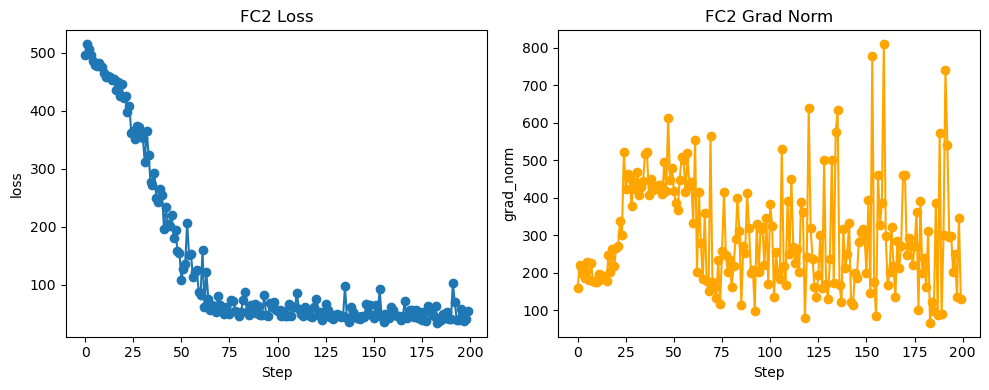

In [5]:
# === Plot FC2 loss and grad norm ===
import matplotlib.pyplot as plt

fc2_vals = [e.get('fc2') for e in epoch_losses if e.get('fc2') is not None]
grad_vals = [e.get('fc2_grad_norm') for e in epoch_losses if e.get('fc2_grad_norm') is not None]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(fc2_vals, marker='o')
ax[0].set_title('FC2 Loss')
ax[0].set_xlabel('Step')
ax[0].set_ylabel('loss')

ax[1].plot(grad_vals, marker='o', color='orange')
ax[1].set_title('FC2 Grad Norm')
ax[1].set_xlabel('Step')
ax[1].set_ylabel('grad_norm')

plt.tight_layout()
plt.show()


In [1]:
# === Episode > 0 FC2 training test ===
import sys
from pathlib import Path
import torch

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'experiments':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import Config
from models import PolicyValueModel, FC2Model
from training.episode import Episode

_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

models = {
    'policy_value': PolicyValueModel().to(_device),
    'fc2': FC2Model(input_dim=Config.FC2_INPUT_DIM, hidden_dims=Config.FC2_HIDDEN_DIMS).to(_device),
}

optimizers = {
    'policy_value': torch.optim.Adam(models['policy_value'].parameters(), lr=1e-3),
    'fc2': torch.optim.Adam(models['fc2'].parameters(), lr=1e-4),
}

episode = Episode(models=models, optimizers=optimizers, config=Config, device=_device, episode_id=1)

summary = episode.run_episode(
    n_epochs=2,
    batch_size=1,
    log_interval=1,
    n_paths=1,
    group_size=50,
    n_branches=2,
    train_modules=['fc2'],
    simulate_kwargs={'horizon': 2}
)

print('episode_id:', summary.get('episode_id'))
print('fc2 summary:', summary['module_summaries'].get('fc2'))


Simulating paths: 100%|██████████| 1/1 [00:00<00:00, 44.77it/s]


RuntimeError: The expanded size of the tensor (1000) must match the existing size (1150) at non-singleton dimension 0.  Target sizes: [1000, 5].  Tensor sizes: [1150, 5]

In [2]:
# === Inspect df_firm ===
import pandas as pd

if 'df' in globals():
    df_firm = df
elif hasattr(episode, 'df'):
    df_firm = episode.df
else:
    df_firm = None

if df_firm is None:
    print('df_firm not found')
else:
    print('df_firm shape:', df_firm.shape)
    print('paths:', df_firm['path'].nunique() if 'path' in df_firm.columns else 'N/A')
    display(df_firm.head())
    if {'path','branch','ID'}.issubset(df_firm.columns):
        dup = df_firm.groupby(['path','branch','ID']).size()
        print('max duplicate per (path,branch,ID):', dup.max())
        print('rows with duplicates >1:', (dup > 1).sum())
        print('max rows per path:', df_firm.groupby('path').size().max())


df_firm shape: (330, 27)
paths: 1


,path,t,branch,ID,entry,b,z,ETA,i,x,...,Bar_i,Bar_z,P,bp0,bpI,bp,Y,I,Phi,C
0,0,0,-1,5a5d343747994a0dbf1fa49a494d5a07,1.0,0.196826,0.022743,0.0,0.036071,-2.047889,...,0.376866,1.797182e-15,0.679051,0.462695,0.544935,0.493689,0.128844,0.032797,1.191667e-15,0.096047
1,0,0,-1,d91c16c5439f4c72a0629f5137dbe77d,1.0,0.415336,0.691220,0.0,0.336855,-2.047889,...,0.398500,1.804574e-15,0.678969,0.475967,0.532535,0.498509,0.264213,0.158247,1.396970e-15,0.105966
2,0,0,-1,0c6774f8566c4aa689a136226028dc7e,1.0,0.018175,-0.717767,1.0,0.355550,-2.047889,...,0.345579,4.059045e-15,0.662757,0.462035,0.538441,0.488439,0.091973,0.208792,3.783148e-15,-0.116819
3,0,0,-1,f04f9998d884495eacb366ef895c0844,1.0,0.351196,-0.116236,0.0,0.175100,-2.047889,...,0.367770,1.809185e-15,0.678918,0.461446,0.542797,0.491364,0.141971,0.104326,1.495955e-15,0.037645
4,0,0,-1,d6242240b8c746d796bc5b3dd6102d00,1.0,0.002626,1.579140,0.0,0.264115,-2.047889,...,0.385218,9.057574e-16,0.692755,0.483791,0.536524,0.504105,0.791965,0.154071,1.118169e-15,0.637894


max duplicate per (path,branch,ID): 2
rows with duplicates >1: 150
max rows per path: 330


In [7]:
episode.df.groupby(['path','branch']).size()

path  branch
0     -1        110
       0        110
       1        110
dtype: int64

In [4]:
# Test fill_df_to_fullN
from experiments.fill_fullN_entrants import fill_df_to_fullN

# reuse df from previous cells if available
df_firm = episode.df if 'episode' in globals() else (df if 'df' in globals() else None)
assert df_firm is not None, 'df/episode not found; run data build cell first'

full_N = getattr(Config, 'FULL_N', 1000)
entry_num = getattr(Config, 'ENTRY_NUM', None)
device = _device if '_device' in globals() else 'cpu'
df_firm_change = df_firm.copy()
df_firm_change['path'] = df_firm_change['path'].astype(str) + '_' +df_firm_change['t'].astype(str)
df_firm_change['branch'] = df_firm_change['branch'] + 1
df_filled = fill_df_to_fullN(df_firm_change, full_N=full_N, device=device, entry_num=entry_num)
print('df_firm shape:', df_firm_change.shape)
print('df_filled shape:', df_filled.shape)
print('rows per path (filled):')
print(df_filled.groupby('path').size().describe())
display(df_filled.head())


ValueError: path 0_0 缺少 branch=1 数据行以提供宏观状态

In [5]:
df_filled

NameError: name 'df_filled' is not defined

In [18]:
df_firm_change

,path,t,branch,ID,entry,b,z,ETA,i,x,...,Bar_i,Bar_z,P,bp0,bpI,bp,Y,I,Phi,C
0,0_0,0,0,1cd5549a73f84c5aa1bfcb9f51a38bc8,1.0,0.436080,-0.753215,0.0,0.186042,-1.989084,...,0.092046,1.146721e-20,0.918296,0.589630,0.494078,0.580835,0.083810,0.048297,9.527645e-21,0.035513
1,0_0,0,0,000d7b43b44f4fb199ed5a38b82b70ac,1.0,0.019362,0.193811,0.0,0.006175,-1.989084,...,0.104496,8.069240e-21,0.925325,0.610239,0.491961,0.597880,0.204803,0.025459,6.961882e-21,0.179345
2,0_0,0,0,5d5e7e055cbe425c995e28ba2fb88d47,1.0,0.417269,-0.425019,0.0,0.198912,-1.989084,...,0.094731,1.368133e-20,0.914765,0.595694,0.494989,0.586154,0.073743,0.032023,7.372910e-21,0.041720
3,0_0,0,0,e86811e09ecc44a9aadf8e8e82362da8,1.0,0.240427,0.690701,0.0,0.479751,-1.989084,...,0.099306,9.978597e-21,0.921077,0.608588,0.485640,0.596379,0.158874,0.039369,4.435824e-21,0.119506
4,0_0,0,0,a6df4b98c1fb4a0fb6f5c34cb0ba9f58,1.0,0.219074,-0.476027,0.0,0.243909,-1.989084,...,0.095815,1.227360e-20,0.916937,0.598909,0.495516,0.589002,0.095248,0.048599,8.953481e-21,0.046648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,0_2,2,2,28bf0921a208477f81c16616a62d83bc,0.0,0.000000,0.154477,0.0,0.077541,-1.992965,...,0.329425,6.588570e-18,0.791224,0.675768,0.396415,0.583742,0.166421,0.047652,4.794028e-18,0.118769
326,0_2,2,2,c91a963c70e84bff97e9ca56f3792b1d,0.0,0.000000,-0.334843,0.0,0.185571,-1.992965,...,0.336745,7.117288e-18,0.789680,0.659900,0.395604,0.570899,0.101957,0.086253,4.900573e-18,0.015704
327,0_2,2,2,98a6784ef965441fa7196364342c33dc,0.0,0.000000,1.294131,0.0,0.376099,-1.992965,...,0.257926,1.418603e-18,0.821937,0.707462,0.411033,0.631005,0.512187,0.120541,1.312833e-18,0.391646
328,0_2,2,2,3163a911b4c84636adb10f16e0231d14,0.0,0.000000,0.649440,0.0,0.045312,-1.992965,...,0.303724,4.237963e-18,0.800049,0.692519,0.398672,0.603271,0.270032,0.034941,3.318164e-18,0.235091


In [15]:
# 1) 每个 path 有多少个 t？
print(df.groupby('path')['t'].nunique().describe())

# 2) 同一个 (path, ID) 在不同 t 出现的次数
dup = df.groupby(['path','ID']).size().reset_index(name='n')
print(dup['n'].describe())

# 3) branch 分布
print(df['branch'].value_counts().sort_index())

# 4) 是否有 Entry 列
print('Entry in df:', 'Entry' in df.columns, 'entry' in df.columns)


count    1.0
mean     3.0
std      NaN
min      3.0
25%      3.0
50%      3.0
75%      3.0
max      3.0
Name: t, dtype: float64
count    70.000000
mean      2.428571
std       0.910032
min       1.000000
25%       1.000000
50%       3.000000
75%       3.000000
max       3.000000
Name: n, dtype: float64
0    50
1    60
2    60
Name: branch, dtype: int64
Entry in df: True False


In [5]:
# SimulateTS quick test (episode>0 style)
import torch
from config import Config
from data.simulate_ts import SimulateTS
from models import PolicyValueModel, SDFFC1Combined

_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# reuse existing models if defined
if 'models' in globals():
    _models = models
else:
    _models = {
        'policy_value': PolicyValueModel().to(_device),
        'sdf_fc1': SDFFC1Combined().to(_device),
        'fc2': None,
    }

sim = SimulateTS(
    models=_models,
    config=Config,
    n_paths=2,
    group_size=50,
    horizon=10,
    branch_num=2,
    device=_device,
)
df_firm_ts, df_macro_ts = sim.simulate()
print('df_firm_ts shape:', df_firm_ts.shape)
print('df_macro_ts shape:', df_macro_ts.shape)
display(df_firm_ts.head())
display(df_macro_ts.head())


Simulating paths: 100%|██████████| 2/2 [00:00<00:00,  9.83it/s]

df_firm_ts shape: (6100, 27)
df_macro_ts shape: (60, 9)


,path,t,branch,ID,entry,b,z,ETA,i,x,...,Bar_i,Bar_z,P,bp0,bpI,bp,Y,I,Phi,C
0,0,0,-1,daf0ca5b181b48d395b2b8a881bf65be,1.0,0.110110,-0.445586,0.0,0.121443,-1.937147,...,0.314557,9.918130e-16,0.690940,0.506637,0.559982,0.523417,0.008329,0.005252,5.866031e-17,0.003077
1,0,0,-1,2618f9a00a0449d88fba93463f728120,1.0,0.385231,-0.192298,0.0,0.314079,-1.937147,...,0.282011,8.247928e-16,0.694628,0.505037,0.555387,0.519236,0.139767,0.127625,6.508766e-16,0.012142
2,0,0,-1,de456f5dc5f942d489507a07edd5a1fe,1.0,0.443840,0.607643,0.0,0.436379,-1.937147,...,0.288060,1.730707e-16,0.725857,0.505746,0.559822,0.521323,0.224113,0.123405,1.112229e-16,0.100708
3,0,0,-1,2589bb826d6f4309b666467fb995c344,1.0,0.392723,-1.136758,0.0,0.157040,-1.937147,...,0.296972,1.542704e-15,0.682105,0.498902,0.573777,0.521138,0.053737,0.077440,1.125430e-15,-0.023703
4,0,0,-1,ef7ff49db908450d840184e1f727194d,1.0,0.478408,-0.688094,0.0,0.271700,-1.937147,...,0.284688,1.470296e-15,0.683066,0.501506,0.564893,0.519551,0.004170,0.005606,5.447618e-17,-0.001435


,path,t,branch,K,C,LnK,Hatc,n_firms,M
0,0,0,-1,30.640406,2.004247,3.422320,-2.726898,50,NaN
1,0,1,0,41.865147,4.060219,3.734454,-2.333114,60,4.077178e+09
2,0,1,1,41.865147,2.964150,3.734454,-2.647722,60,4.179604e+09
3,0,1,-1,41.865147,4.423657,3.734454,-2.247392,60,4.077178e+09
4,0,2,0,53.470158,4.262868,3.979124,-2.529056,70,2.246712e+09


In [6]:
df_firm_ts.groupby(['path','t','branch']).size()

path  t   branch
0     0   -1         50
      1   -1         60
           0         60
           1         60
      2   -1         70
           0         70
           1         70
      3   -1         80
           0         80
           1         80
      4   -1         90
           0         90
           1         90
      5   -1        100
           0        100
           1        100
      6   -1        110
           0        110
           1        110
      7   -1        120
           0        120
           1        120
      8   -1        130
           0        130
           1        130
      9   -1        140
           0        140
           1        140
      10   0        150
           1        150
1     0   -1         50
      1   -1         60
           0         60
           1         60
      2   -1         70
           0         70
           1         70
      3   -1         80
           0         80
           1         80
      4   -1         90

In [12]:
# Sample quick test
import torch
from config import Config
from data.sample import Sample

_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if 'models' in globals():
    _models = models
else:
    _models = {}

sampler = Sample(
    models=_models,
    config=Config,
    n_samples=None,
    n_paths=3,
    group_size=50,
    branch_num=2,
    data_mode='simulate',
    device=_device,
)
df_firm, df_macro = sampler.build_df()
print('df_firm shape:', df_firm.shape)
print('df_macro shape:', df_macro.shape)
print('branch counts:', df_firm['branch'].value_counts().sort_index().to_dict())
display(df_firm.head())
display(df_macro.head())


Generating simulate data: 100%|██████████| 3/3 [00:00<00:00, 120.74it/s]

df_firm shape: (510, 24)
df_macro shape: (9, 16)
branch counts: {0: 150, 1: 180, 2: 180}


,path,ID,t,branch,b,z,ETA,i,x,Hatcf,...,Q,bp0,bpI,P0,PI,Bar_i,Bar_z,P,Phat,bp
0,0,372210e2283a494aa1b5ccd93577554f,t,0,0.327904,-0.153399,0.0,0.305394,-2.013083,-1.953023,...,0.675816,0.428055,0.556563,0.695839,0.622203,0.323801,7.763419e-16,0.695839,0.695839,0.469666
1,0,372210e2283a494aa1b5ccd93577554f,t+1_0,1,0.327904,0.460981,0.0,0.232309,-2.008935,-1.963059,...,0.650560,0.437454,0.559664,0.693759,0.623394,0.331004,8.614326e-16,0.693759,0.693759,0.477906
2,0,372210e2283a494aa1b5ccd93577554f,t+1_1,2,0.327904,-0.141342,0.0,0.199155,-2.023447,-1.940259,...,0.675506,0.427681,0.559883,0.695711,0.618874,0.316830,7.813092e-16,0.695711,0.695711,0.469567
3,0,9fa68b11b20d4424826f663b7246c97c,t,0,0.189369,-0.397463,0.0,0.486053,-2.013083,-1.953023,...,0.675679,0.421366,0.550547,0.695907,0.628079,0.336647,7.737135e-16,0.695907,0.695907,0.464855
4,0,9fa68b11b20d4424826f663b7246c97c,t+1_0,1,0.189369,-0.650423,0.0,0.462509,-2.008935,-1.963059,...,0.680449,0.420615,0.552210,0.694281,0.624005,0.331200,8.392272e-16,0.694281,0.694281,0.464199


,path,t,branch,x,n_firms,n_entrants,Hatcf,LnKF,M,Y,C,K,I,Phi,LnK,Hatc
0,0,t,-1,-2.013083,50,20,-1.953023,3.874930,1.0,10.520369,5.355939,50.0,5.164431,4.017200e-14,3.912023,-2.233817
1,0,t+1_0,0,-2.008935,50,10,-1.963059,3.874846,NaN,10.564101,5.399671,50.0,5.164431,4.021085e-14,3.912023,-2.225685
2,0,t+1_1,1,-2.023447,50,10,-1.940259,3.867061,NaN,10.411899,5.247468,50.0,5.164431,4.007564e-14,3.912023,-2.254277
3,1,t,-1,-2.036046,50,20,-1.930329,3.835767,1.0,9.034662,3.808998,50.0,5.225664,3.702229e-14,3.912023,-2.574657
4,1,t+1_0,0,-2.024441,50,10,-1.943450,3.854608,NaN,9.140122,3.914458,50.0,5.225664,3.710361e-14,3.912023,-2.547346


In [13]:
df_firm.groupby(['path','t','branch']).size()

path  t      branch
0     t      0         50
      t+1_0  1         60
      t+1_1  2         60
1     t      0         50
      t+1_0  1         60
      t+1_1  2         60
2     t      0         50
      t+1_0  1         60
      t+1_1  2         60
dtype: int64

In [9]:
import numpy as np
def convert_tree_fast(df):
    
    df = df.copy()

    df['path_ori'] = df['path']
    df['t_ori'] = df['t']
    df['branch_ori'] = df['branch']

    # parent时间
    parent_t = np.where(
        df['branch'] == -1,
        df['t'],
        df['t'] - 1
    )

    # 直接编码 parent state
    state_keys = list(zip(df['path_ori'], parent_t))

    df['path'] = pd.factorize(state_keys)[0].astype('int32')

    # branch映射
    df['branch'] = df['branch'].map({-1:0, 0:1, 1:2}).astype('int8')

    # t label
    df['t'] = np.select(
        [
            df['branch']==0,
            df['branch']==1,
            df['branch']==2
        ],
        ['t','t+1_0','t+1_1']
    )

    df = df.sort_values(['path','branch'], kind='mergesort')

    return df


In [10]:
df_new = convert_tree_fast(df_firm_ts)


In [28]:
df_firm_ts.groupby(['path','t','branch']).size()

path  t   branch
0     0   -1         50
      1   -1         60
           0         50
           1         50
      2   -1         70
           0         60
           1         60
      3   -1         80
           0         70
           1         70
      4   -1         90
           0         80
           1         80
      5   -1        100
           0         90
           1         90
      6   -1        110
           0        100
           1        100
      7   -1        120
           0        110
           1        110
      8   -1        130
           0        120
           1        120
      9   -1        140
           0        130
           1        130
      10   0        140
           1        140
1     0   -1         50
      1   -1         60
           0         50
           1         50
      2   -1         70
           0         60
           1         60
      3   -1         80
           0         70
           1         70
      4   -1         90

In [31]:
df_new[df_new['path'] == 1]

,path,t,branch,ID,entry,b,z,ETA,i,x,...,bp0,bpI,bp,Y,I,Phi,C,path_ori,t_ori,branch_ori
150,1,t,0,f4ba0efd65fe454398b978bd0a99b556,0.0,0.286131,0.149650,0.0,0.008480,-1.920747,...,0.426366,0.570599,0.469556,0.248565,0.032927,6.380287e-16,0.215638,0,1,-1
151,1,t,0,f9326625fd774366ad53114084e3d09a,0.0,0.497899,-0.003418,1.0,0.246494,-1.920747,...,0.454743,0.570508,0.497179,0.158503,0.119811,5.864383e-16,0.038692,0,1,-1
152,1,t,0,305a11bf4a864f87b1c71f8f531f0ce2,0.0,0.327450,1.110483,0.0,0.386978,-1.920747,...,0.438958,0.555882,0.477516,0.396243,0.131517,8.084780e-16,0.264726,0,1,-1
153,1,t,0,563745f7192e4475836e727f66336756,0.0,0.290664,0.462028,0.0,0.015215,-1.920747,...,0.431549,0.572103,0.473969,0.186510,0.019725,3.911734e-16,0.166786,0,1,-1
154,1,t,0,0909da8a7a16410aacdbed6617e5b109,0.0,0.411659,0.029605,0.0,0.353504,-1.920747,...,0.427153,0.553655,0.466881,0.097365,0.084537,3.011162e-16,0.012828,0,1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,1,t+1_1,2,bb07bcaa5cae417ca4e839b30157728f,0.0,0.000000,0.497614,0.0,0.359363,-1.939632,...,0.425918,0.562398,0.469323,0.246050,0.139741,4.388453e-16,0.106309,0,2,1
326,1,t+1_1,2,a51bb336e1b0486dbfc4f3553d426005,0.0,0.000000,1.392171,0.0,0.012048,-1.939632,...,0.430580,0.581583,0.476728,0.607163,0.024859,1.133837e-15,0.582304,0,2,1
327,1,t+1_1,2,fd7e4b00043c420cb49978181c80cbda,0.0,0.000000,0.846262,0.0,0.008363,-1.939632,...,0.428225,0.578336,0.472829,0.350061,0.023490,5.893218e-16,0.326571,0,2,1
328,1,t+1_1,2,6105148a8bab4b378defe3d3ec7c5b44,0.0,0.000000,-0.432763,0.0,0.210253,-1.939632,...,0.410249,0.564954,0.455067,0.097058,0.084209,3.484360e-16,0.012849,0,2,1


In [11]:
df_new.groupby(['path','t','branch']).size()

path  t      branch
0     t      0          50
      t+1_0  1          60
      t+1_1  2          60
1     t      0          60
      t+1_0  1          70
      t+1_1  2          70
2     t      0          70
      t+1_0  1          80
      t+1_1  2          80
3     t      0          80
      t+1_0  1          90
      t+1_1  2          90
4     t      0          90
      t+1_0  1         100
      t+1_1  2         100
5     t      0         100
      t+1_0  1         110
      t+1_1  2         110
6     t      0         110
      t+1_0  1         120
      t+1_1  2         120
7     t      0         120
      t+1_0  1         130
      t+1_1  2         130
8     t      0         130
      t+1_0  1         140
      t+1_1  2         140
9     t      0         140
      t+1_0  1         150
      t+1_1  2         150
10    t      0          50
      t+1_0  1          60
      t+1_1  2          60
11    t      0          60
      t+1_0  1          70
      t+1_1  2          70
12    t 